# 076: HP Alphabet Sweep — Per-class Sensitivity & FoldSeek Comparison

Loads AUC cache from 075. Selects best alphabet, runs per-class SCOPe sensitivity analysis, head-to-head vs FoldSeek/TEA, enrichment, TP/FP validation, and 3-method detection comparison.

**Depends on:** 075 (AUC cache parquet)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gc
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from scipy.stats import chi2_contingency

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    EVAL_USECOLS, TEA_DIR, SCOPE_CLASS_DESCRIPTIONS,
    load_baselines, add_composite_scores_scope, recompute_bonferroni,
    eval_tsv_to_rocx, sensitivity_stats,
)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
SWEEP_DIR  = Path.home() / 'data/scope/results-hp-alphabet-sweep'
FIG_PREFIX = '../figures/076'
Path('../figures').mkdir(exist_ok=True)

# ---------------------------------------------------------------------------
# Alphabet definitions (same order as Nextflow pipeline)
# ---------------------------------------------------------------------------
NAMED_LABELS = [
    'hp_thomas_dill',
    'hp_kyte_doolittle',
    'hp_thomas_dill_no_c',
    'hp_lehninger_plus_c',
    'hp_pbotc_1st_ed',
    'hp_shuffled_control',
]
SEED_LABELS = [f'hp_shuffled_control_{i}' for i in range(1, 11)]
ALL_LABELS  = NAMED_LABELS + SEED_LABELS

KSIZES = list(range(20, 41))   # pipeline ran k=20–40

BONF_THRESHOLD = 0.05
NQUERY_MINS    = [200, 150, 100]  # coverage thresholds for best-k search

# Named-alphabet colours (shuffled controls will use grey tones)
NAMED_COLORS = {
    'hp_thomas_dill':       'tomato',
    'hp_kyte_doolittle':    'steelblue',
    'hp_thomas_dill_no_c':  'seagreen',
    'hp_lehninger_plus_c':  'navy',
    'hp_pbotc_1st_ed':      'mediumpurple',
    'hp_shuffled_control':  'saddlebrown',
}

print('SWEEP_DIR:', SWEEP_DIR)
print('N alphabets:', len(ALL_LABELS))
print('K-sizes:', KSIZES[0], '–', KSIZES[-1])

SWEEP_DIR: /Users/olga/data/scope/results-hp-alphabet-sweep
N alphabets: 16
K-sizes: 20 – 40


In [3]:
def eval_path(label: str, k: int) -> Path:
    gz = SWEEP_DIR / f'scope_eval.{label}.k{k}.tsv.gz'
    return gz if gz.exists() else SWEEP_DIR / f'scope_eval.{label}.k{k}.tsv'


def has_data(label: str, k: int) -> bool:
    p = eval_path(label, k)
    return p.exists() and p.stat().st_size > 0


available = {(lbl, k): has_data(lbl, k) for lbl in ALL_LABELS for k in KSIZES}
n_avail   = sum(available.values())
n_total   = len(available)

print(f'Available eval files: {n_avail} / {n_total}')
if n_avail == 0:
    print()
    print('⚠️  No eval files have data yet.')
    print('   The pipeline ran but kmerseek search wrote 0 rows to its output CSV.')
    print('   Check the search logs in SWEEP_DIR for details.')
    print('   Re-run the pipeline after fixing the kmerseek search output bug.')
    print()
    # Show example log to confirm matches were found
    example_log = SWEEP_DIR / 'scope40.hp_thomas_dill.k25.search.log'
    if example_log.exists():
        print(f'Example log ({example_log.name}):')
        for line in example_log.read_text().splitlines()[-8:]:
            print(' ', line)
else:
    by_label = {lbl: sum(available[(lbl, k)] for k in KSIZES) for lbl in ALL_LABELS}
    for lbl, n in sorted(by_label.items(), key=lambda x: -x[1]):
        print(f'  {lbl:<35s}: {n}/{len(KSIZES)} k-sizes')

Available eval files: 336 / 336
  hp_thomas_dill                     : 21/21 k-sizes
  hp_kyte_doolittle                  : 21/21 k-sizes
  hp_thomas_dill_no_c                : 21/21 k-sizes
  hp_lehninger_plus_c                : 21/21 k-sizes
  hp_pbotc_1st_ed                    : 21/21 k-sizes
  hp_shuffled_control                : 21/21 k-sizes
  hp_shuffled_control_1              : 21/21 k-sizes
  hp_shuffled_control_2              : 21/21 k-sizes
  hp_shuffled_control_3              : 21/21 k-sizes
  hp_shuffled_control_4              : 21/21 k-sizes
  hp_shuffled_control_5              : 21/21 k-sizes
  hp_shuffled_control_6              : 21/21 k-sizes
  hp_shuffled_control_7              : 21/21 k-sizes
  hp_shuffled_control_8              : 21/21 k-sizes
  hp_shuffled_control_9              : 21/21 k-sizes
  hp_shuffled_control_10             : 21/21 k-sizes


In [4]:
foldseek, tea_all = load_baselines(TEA_DIR)
ref_queries = set(foldseek['NAME'].to_list())

_, _, fs_fam  = sensitivity_stats(foldseek, 'FAM')
_, _, fs_sfam = sensitivity_stats(foldseek, 'SFAM')
_, _, fs_fold = sensitivity_stats(foldseek, 'FOLD')
_, _, tea_fam  = sensitivity_stats(tea_all,  'FAM')
_, _, tea_sfam = sensitivity_stats(tea_all,  'SFAM')
_, _, tea_fold = sensitivity_stats(tea_all,  'FOLD')

print(f'FoldSeek: {foldseek["NAME"].n_unique():,} queries  FAM={fs_fam:.4f}  SFAM={fs_sfam:.4f}  FOLD={fs_fold:.4f}')
print(f'TEA:      {tea_all["NAME"].n_unique():,} queries  FAM={tea_fam:.4f}  SFAM={tea_sfam:.4f}  FOLD={tea_fold:.4f}')
print(f'Benchmarkable query set: {len(ref_queries):,}')

FoldSeek: 5,713 queries  FAM=0.8169  SFAM=0.5743  FOLD=0.1017
TEA:      5,737 queries  FAM=0.8020  SFAM=0.5804  FOLD=0.0868
Benchmarkable query set: 5,713


In [5]:
def load_eval_alphabet(
    label: str, k: int, columns=None
) -> pl.DataFrame:
    """Load scope_eval file for a given alphabet label and k-size."""
    path = eval_path(label, k)
    if not path.exists():
        raise FileNotFoundError(f'Missing: {path}')
    if path.stat().st_size == 0:
        raise FileNotFoundError(f'Empty: {path}')
    df = pl.read_csv(path, separator='\t')
    if columns is not None:
        df = df.select([c for c in columns if c in df.columns])
    return df

In [6]:
CACHE_PATH = SWEEP_DIR / 'auc_sweep_bonf_jaccard.parquet'
FORCE_RECOMPUTE = False

if not FORCE_RECOMPUTE and CACHE_PATH.exists():
    auc_df = pl.read_parquet(CACHE_PATH)
    print(f'Loaded cached AUC sweep: {len(auc_df):,} rows')
else:
    rows = []
    for label in ALL_LABELS:
        print(f'{label}:', end=' ', flush=True)
        for k in KSIZES:
            try:
                ev = load_eval_alphabet(label, k, columns=EVAL_USECOLS)
            except FileNotFoundError:
                print('_', end='', flush=True)
                continue
            ev = add_composite_scores_scope(ev)
            ev = recompute_bonferroni(ev)
            ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)

            rocx   = eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False,
                                       exclude_gray_zone=True)
            rocx_r = rocx.filter(pl.col('NAME').is_in(ref_queries))

            def _aucs(r, level):
                return sensitivity_stats(r, level)[2]

            rows.append(dict(
                label=label, ksize=k,
                n_queries_all=rocx['NAME'].n_unique(),
                n_queries_ref=rocx_r['NAME'].n_unique(),
                auc_fam_all =round(_aucs(rocx,   'FAM'),  5),
                auc_sfam_all=round(_aucs(rocx,   'SFAM'), 5),
                auc_fold_all=round(_aucs(rocx,   'FOLD'), 5),
                auc_fam_ref =round(_aucs(rocx_r, 'FAM'),  5),
                auc_sfam_ref=round(_aucs(rocx_r, 'SFAM'), 5),
                auc_fold_ref=round(_aucs(rocx_r, 'FOLD'), 5),
            ))
            print('.', end='', flush=True)
            del ev, ev_filt, rocx, rocx_r; gc.collect()
        print()

    if rows:
        auc_df = pl.DataFrame(rows)
        auc_df.write_parquet(CACHE_PATH)
        print(f'Saved {len(auc_df):,} rows → {CACHE_PATH.name}')
    else:
        print('No data available — auc_df is empty (pipeline results missing)')
        auc_df = pl.DataFrame(schema={
            'label': pl.Utf8, 'ksize': pl.Int64,
            'n_queries_all': pl.Int64, 'n_queries_ref': pl.Int64,
            'auc_fam_all': pl.Float64, 'auc_sfam_all': pl.Float64, 'auc_fold_all': pl.Float64,
            'auc_fam_ref': pl.Float64, 'auc_sfam_ref': pl.Float64, 'auc_fold_ref': pl.Float64,
        })

Loaded cached AUC sweep: 336 rows


In [7]:
def best_ksize_for_label(auc_df, label, nquery_min=None, level_col='auc_fam_ref'):
    """Return best k-size row for a given alphabet and coverage threshold."""
    sub = auc_df.filter(pl.col('label') == label)
    if nquery_min is not None:
        sub = sub.filter(pl.col('n_queries_ref') >= nquery_min)
    if sub.height == 0:
        return None
    return sub.sort(level_col, descending=True).row(0, named=True)


if auc_df.height > 0:
    print(f'=== Best k-sizes per alphabet (Bonferroni<{BONF_THRESHOLD} + Jaccard, excl. gray zone) ===\n')
    header = f'{"Alphabet":<35} {"Overall":>10} {"n≥200":>10} {"n≥150(≈1%)":>12} {"n≥100":>10}'
    print(header)
    print('-' * len(header))

    best_ks = {}  # label → best (overall) row
    for label in ALL_LABELS:
        best_overall = best_ksize_for_label(auc_df, label, nquery_min=None)
        best_200     = best_ksize_for_label(auc_df, label, nquery_min=200)
        best_150     = best_ksize_for_label(auc_df, label, nquery_min=150)
        best_100     = best_ksize_for_label(auc_df, label, nquery_min=100)

        def fmt(row):
            if row is None:
                return '   —   '
            return f'k={row["ksize"]:2d}(n={row["n_queries_ref"]:3d})'

        print(f'{label:<35} {fmt(best_overall):>10} {fmt(best_200):>10} {fmt(best_150):>10} {fmt(best_100):>10}')
        best_ks[label] = best_overall
else:
    print('No data — skipping best-k summary.')
    best_ks = {lbl: None for lbl in ALL_LABELS}

=== Best k-sizes per alphabet (Bonferroni<0.05 + Jaccard, excl. gray zone) ===

Alphabet                               Overall      n≥200   n≥150(≈1%)      n≥100
---------------------------------------------------------------------------------
hp_thomas_dill                      k=30(n= 84) k=26(n=228) k=27(n=167) k=29(n=103)
hp_kyte_doolittle                   k=32(n= 49) k=25(n=248) k=26(n=183) k=28(n=106)
hp_thomas_dill_no_c                 k=30(n= 82) k=26(n=205) k=27(n=151) k=29(n=101)
hp_lehninger_plus_c                 k=29(n= 62) k=24(n=227) k=25(n=175) k=26(n=136)
hp_pbotc_1st_ed                     k=29(n= 77) k=25(n=234) k=26(n=174) k=27(n=124)
hp_shuffled_control                 k=26(n=  8)       —          —          —   
hp_shuffled_control_1               k=23(n= 12)       —          —          —   
hp_shuffled_control_2               k=25(n= 13)       —          —    k=20(n=149)
hp_shuffled_control_3               k=26(n=  6)       —          —          —   
hp_shuffled

## 8. Per-class family sensitivity curves

Uses the best k-size with **n ≥ 1% of SCOPe40** (≈ 150 queries, validated in `per-class-sens`) for each named alphabet.

In [8]:
# Build cls_to_queries from ALL 15,177 SCOPe-40 domains (not just FoldSeek benchmark)
SCOPE_DOMAINS_PATH = Path.home() / 'data/scope/results-scope-pvalue-benchmark/scope_domains.tsv'
scope_domains = pl.read_csv(SCOPE_DOMAINS_PATH, separator='\t')

cls_to_queries = defaultdict(set)
for domain_id, cls in scope_domains.select(['domain_id', 'scop_class']).iter_rows():
    cls_to_queries[cls].add(domain_id)
scop_classes = [c for c in sorted(cls_to_queries.keys()) if c != 'e']

n_scope40_total = scope_domains.height
NQUERY_MIN = round(n_scope40_total / 100)  # 1% of all SCOPe40 proteins
_exact_1pct = n_scope40_total / 100
assert abs(NQUERY_MIN - _exact_1pct) <= 5, (
    f'NQUERY_MIN={NQUERY_MIN} is >5 away from 1% of SCOPe40 ({_exact_1pct:.1f})'
)
print(f'Total SCOPe-40 proteins: {n_scope40_total:,}')
print(f'1%% query threshold: NQUERY_MIN = {NQUERY_MIN}  '
      f'(1%% of {n_scope40_total:,} = {_exact_1pct:.1f}  → round = {NQUERY_MIN})')
for cls in scop_classes:
    print(f'  Class {cls}: {len(cls_to_queries[cls]):,}')

# Per-query FAM dicts (absent queries treated as FAM=0 in survival_curve)
def survival_curve(fam_dict, queries):
    """Fraction of queries achieving FAM >= x; absent queries treated as FAM=0."""
    vals = np.sort([fam_dict.get(q, 0.0) for q in queries])
    n = len(vals)
    x = np.concatenate([[0.0], vals, [1.0 + 1e-9]])
    y = np.concatenate([[1.0], 1.0 - np.arange(1, n + 1) / n, [0.0]])
    return x, y


def per_query_fam(rocx_df):
    return dict(zip(rocx_df['NAME'].to_list(), rocx_df['FAM'].to_list()))


fs_fam_dict  = per_query_fam(foldseek)
tea_fam_dict = per_query_fam(tea_all)

try:
    mmseqs_path = Path('/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files/mmseqs.rocx')
    mmseqs = pl.read_csv(mmseqs_path, separator='\t')
    mm_fam_dict = per_query_fam(mmseqs)
except FileNotFoundError:
    mm_fam_dict = {}
    print('MMseqs2 ROCX not found — skipping from per-class plot.')

print('Baseline per-query FAM dicts loaded.')

Total SCOPe-40 proteins: 15,177
1%% query threshold: NQUERY_MIN = 152  (1%% of 15,177 = 151.8  → round = 152)
  Class a: 2,644
  Class b: 3,059
  Class c: 4,463
  Class d: 3,653
  Class f: 332
  Class g: 722
Baseline per-query FAM dicts loaded.


Best alphabet for per-class plot: hp_pbotc_1st_ed  k=26  FAM AUC=0.9425


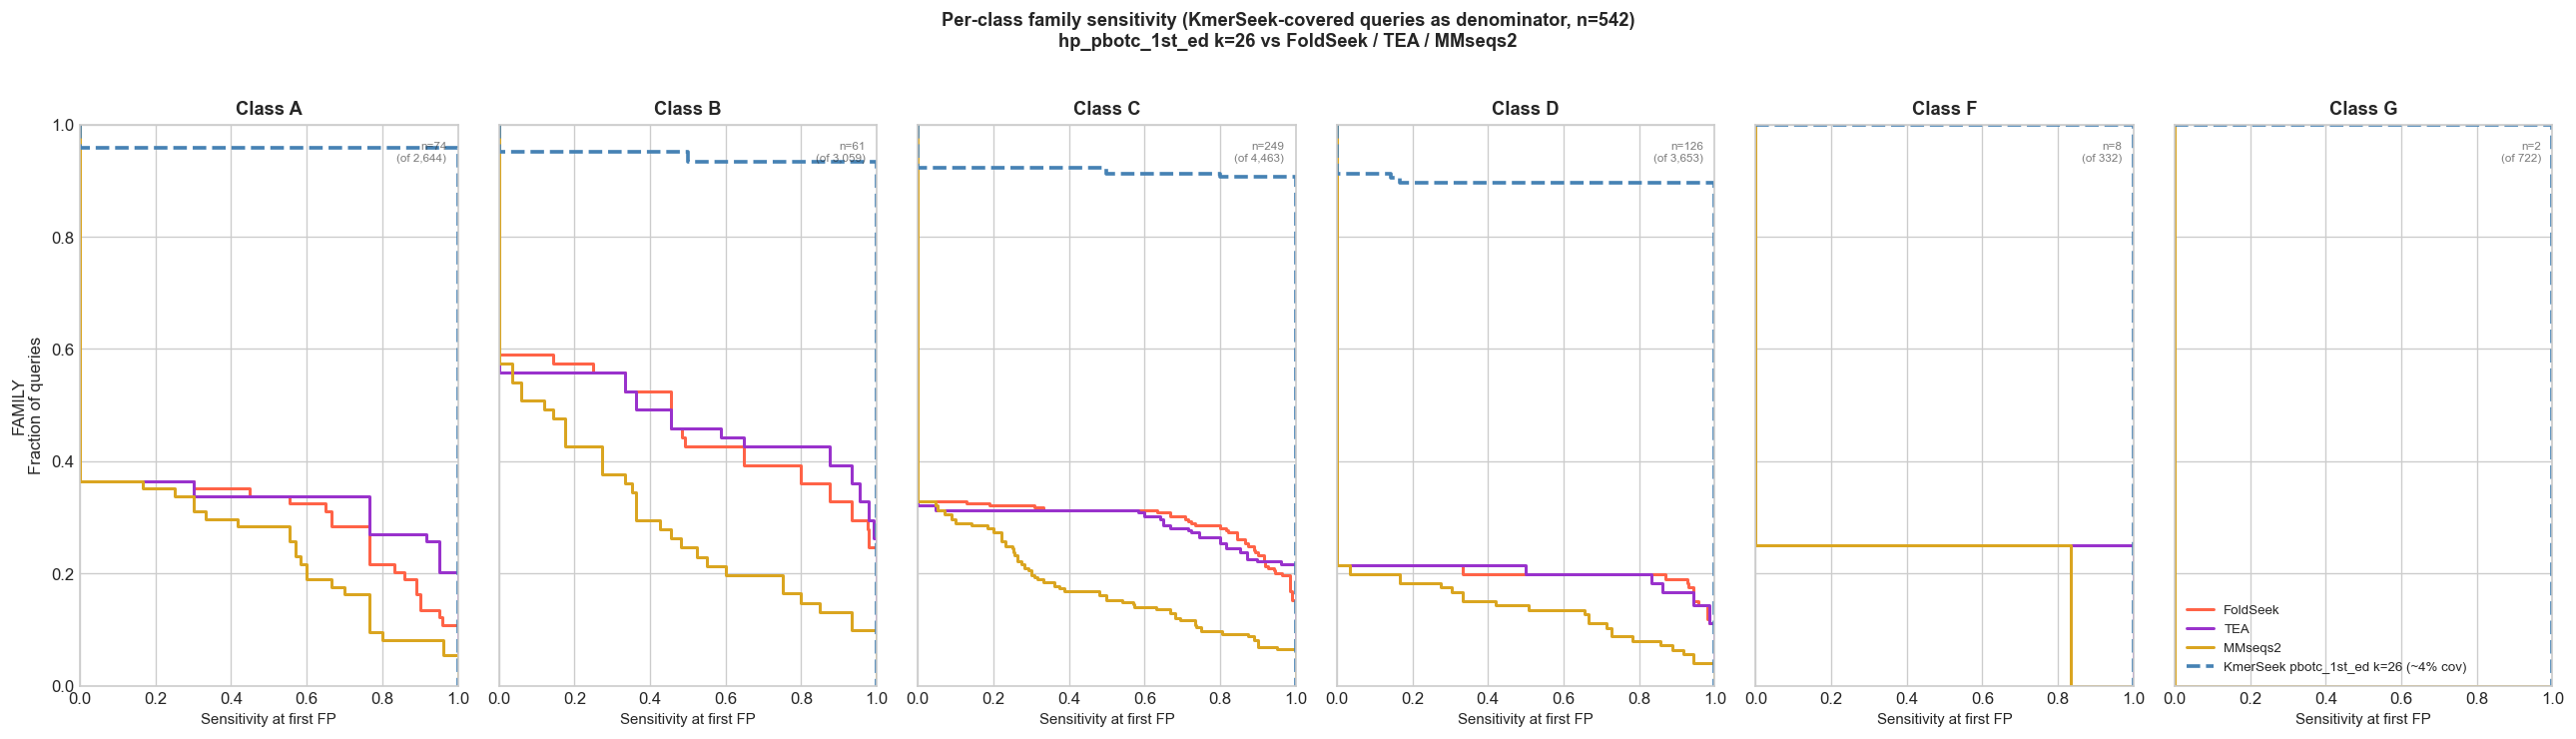

Saved: ../figures/076_per_class_sensitivity.png


In [9]:
if auc_df.height == 0:
    print('No data to plot per-class sensitivity.')
else:
    best_named = None
    best_named_auc = -1.0
    for lbl in NAMED_LABELS:
        row = best_ksize_for_label(auc_df, lbl, nquery_min=NQUERY_MIN)
        if row and row['auc_fam_ref'] > best_named_auc:
            best_named_auc = row['auc_fam_ref']
            best_named = (lbl, row['ksize'])

    if best_named is None:
        print(f'No alphabet has n≥{NQUERY_MIN} (≥1% of SCOPe40) queries — cannot plot per-class sensitivity.')
    else:
        best_label, best_k = best_named
        print(f'Best alphabet for per-class plot: {best_label}  k={best_k}  FAM AUC={best_named_auc:.4f}')

        ev = load_eval_alphabet(best_label, best_k, columns=EVAL_USECOLS)
        ev = add_composite_scores_scope(ev)
        ev = recompute_bonferroni(ev)
        ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
        km_rocx = eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False,
                                    exclude_gray_zone=True)
        km_fam_dict = per_query_fam(km_rocx)
        del ev, ev_filt; gc.collect()

        km_covered = set(km_rocx['NAME'].to_list())
        n_total = scope_domains.height
        km_cov_pct = 100 * len(km_covered) / n_total

        # Skip class 'e' — FoldSeek only did single domain for that class
        scop_classes_plot = scop_classes
        n_cls = len(scop_classes_plot)

        METHODS = [
            ('FoldSeek',    fs_fam_dict,  'tomato',      '-',  1.8),
            ('TEA',         tea_fam_dict, 'darkorchid',  '-',  1.8),
            ('MMseqs2',     mm_fam_dict,  'goldenrod',   '-',  1.8),
            (f'KmerSeek {best_label.replace("hp_","")} k={best_k} (~{km_cov_pct:.0f}% cov)',
             km_fam_dict, 'steelblue', '--', 2.2),
        ]
        METHODS = [(lbl, d, c, ls, lw) for lbl, d, c, ls, lw in METHODS if d]

        # ── Per-class plot: KmerSeek-covered queries as denominator ─────────────
        fig_a, axes_a = plt.subplots(1, n_cls, figsize=(3.6 * n_cls, 6), sharey=True)
        fig_a.subplots_adjust(wspace=0.06)

        for i, (ax, cls) in enumerate(zip(axes_a, scop_classes_plot)):
            queries_all = cls_to_queries[cls]
            queries = queries_all & km_covered
            ax.set_title(f'Class {cls.upper()}', fontsize=11, fontweight='bold')
            for j, (label_, fam_dict, color, ls, lw) in enumerate(METHODS):
                x, y = survival_curve(fam_dict, queries)
                ax.step(x, y, where='post', color=color, lw=lw, ls=ls,
                        label=label_ if i == n_cls - 1 else '_nolegend_')
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.set_xlabel('Sensitivity at first FP', fontsize=9)
            if i == 0:
                ax.set_ylabel('FAMILY\nFraction of queries', fontsize=10)
            ax.text(0.97, 0.97, f'n={len(queries):,}\n(of {len(queries_all):,})',
                    transform=ax.transAxes, fontsize=7, ha='right', va='top', alpha=0.6)

        axes_a[-1].legend(loc='lower left', fontsize=8)
        plt.suptitle(
            f'Per-class family sensitivity (KmerSeek-covered queries as denominator, n={len(km_covered):,})\n'
            f'{best_label} k={best_k} vs FoldSeek / TEA / MMseqs2',
            fontsize=11, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(f'{FIG_PREFIX}_per_class_sensitivity.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Saved: {FIG_PREFIX}_per_class_sensitivity.png')


## 9. KmerSeek unique detections

**"Missed by FoldSeek"** = KmerSeek detections (FAM > 0) for proteins where FoldSeek's benchmark
has no result at all (outside its SCOPe-PDB coverage).  Class e (multidomain) is excluded from all
analyses — FoldSeek never benchmarked those proteins.

**Two categories of KmerSeek unique detections:**

1. **Head-to-head (both methods benchmarked):** Among the proteins in FoldSeek's benchmark,
   KmerSeek at Bonferroni < 0.05 detects a subset that FoldSeek misses (`km_uniq_inside`).

2. **Missed by FoldSeek:** KmerSeek ran all-vs-all on all 15,177 SCOPe-40 sequences (minus class e);
   FoldSeek's benchmark covers only a subset.  Detections outside that coverage are KmerSeek's
   true unique finds — enriched for class c (alpha/beta), consistent with notebooks 059–069.

**Why this was hidden:** The notebook previously filtered KmerSeek results to `ref_queries`
(FoldSeek's benchmark) before computing unique detections, silently dropping all queries outside
that set.


## 8b. Head-to-head ranking: KmerSeek vs FoldSeek on shared queries

For queries where both methods have Bonferroni-significant hits (the shared benchmark),
compare per-query FAM sensitivity — i.e., does KmerSeek rank family members higher?

Shared queries (KM Bonferroni-sig ∩ FS benchmark): 174

Per-query FAM (sensitivity at first FP):
  KmerSeek  mean=0.9454  median=1.0000
  FoldSeek  mean=0.8729  median=0.9861
  KM − FS   mean=+0.0725  median=+0.0139

  KM ranks better (diff > 0): 92 / 174 (53%)
  Tie       (diff = 0):        72 / 174 (41%)
  FS ranks better (diff < 0):  10 / 174 (6%)

  Wilcoxon signed-rank (KM > FS, non-zero pairs=102): stat=4318.5  p=8.077e-09


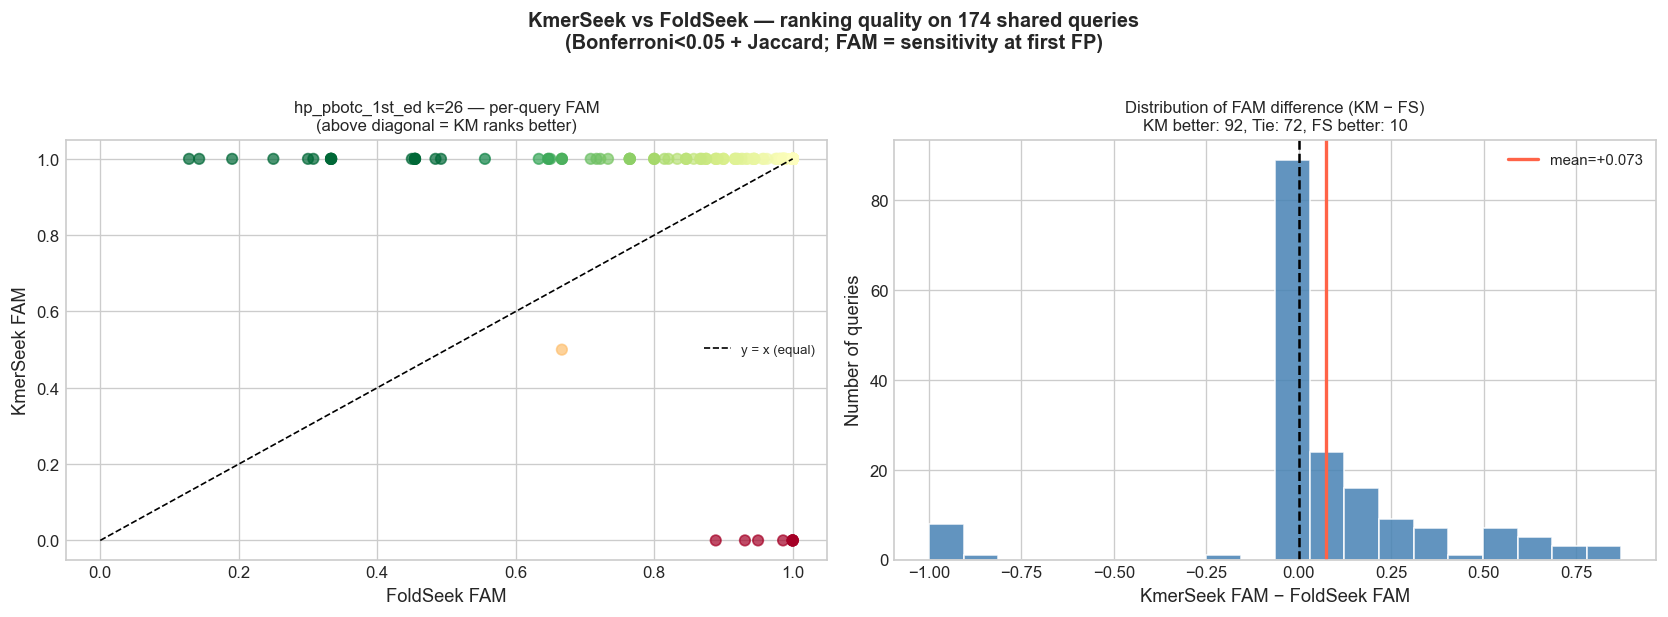

In [10]:
from scipy.stats import wilcoxon

if auc_df.height == 0 or best_named is None:
    print('No data.')
else:
    best_label, best_k = best_named

    ev = load_eval_alphabet(best_label, best_k, columns=EVAL_USECOLS)
    ev = add_composite_scores_scope(ev)
    ev = recompute_bonferroni(ev)
    ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
    km_rocx_r = (eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False, exclude_gray_zone=True)
                 .filter(pl.col('NAME').is_in(ref_queries)))
    del ev, ev_filt; gc.collect()

    km_fam_d = dict(zip(km_rocx_r['NAME'].to_list(), km_rocx_r['FAM'].to_list()))
    fs_fam_d = dict(zip(foldseek['NAME'].to_list(),  foldseek['FAM'].to_list()))

    shared = sorted(set(km_fam_d) & set(fs_fam_d))
    km_arr = np.array([km_fam_d[q] for q in shared])
    fs_arr = np.array([fs_fam_d[q] for q in shared])
    diff   = km_arr - fs_arr

    print(f"Shared queries (KM Bonferroni-sig ∩ FS benchmark): {len(shared)}")
    print(f"\nPer-query FAM (sensitivity at first FP):")
    print(f"  KmerSeek  mean={km_arr.mean():.4f}  median={np.median(km_arr):.4f}")
    print(f"  FoldSeek  mean={fs_arr.mean():.4f}  median={np.median(fs_arr):.4f}")
    print(f"  KM − FS   mean={diff.mean():+.4f}  median={np.median(diff):+.4f}")
    print(f"\n  KM ranks better (diff > 0): {(diff > 0).sum()} / {len(shared)} ({100*(diff>0).mean():.0f}%)")
    print(f"  Tie       (diff = 0):        {(diff == 0).sum()} / {len(shared)} ({100*(diff==0).mean():.0f}%)")
    print(f"  FS ranks better (diff < 0):  {(diff < 0).sum()} / {len(shared)} ({100*(diff<0).mean():.0f}%)")

    # Wilcoxon signed-rank test (paired, ignoring ties)
    nz = diff[diff != 0]
    if len(nz) >= 10:
        stat, pval = wilcoxon(nz, alternative='greater')
        print(f"\n  Wilcoxon signed-rank (KM > FS, non-zero pairs={len(nz)}): stat={stat:.1f}  p={pval:.4g}")

    # Scatter plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.scatter(fs_arr, km_arr, alpha=0.7, s=40,
               c=diff, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='y = x (equal)')
    ax.set_xlabel('FoldSeek FAM', fontsize=11)
    ax.set_ylabel('KmerSeek FAM', fontsize=11)
    ax.set_title(f'{best_label} k={best_k} — per-query FAM\n(above diagonal = KM ranks better)', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)

    ax = axes[1]
    ax.hist(diff, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', lw=1.5, ls='--')
    ax.axvline(diff.mean(), color='tomato', lw=2, ls='-', label=f'mean={diff.mean():+.3f}')
    ax.set_xlabel('KmerSeek FAM − FoldSeek FAM', fontsize=11)
    ax.set_ylabel('Number of queries', fontsize=11)
    ax.set_title(f'Distribution of FAM difference (KM − FS)\n'
                 f'KM better: {(diff>0).sum()}, Tie: {(diff==0).sum()}, FS better: {(diff<0).sum()}',
                 fontsize=10)
    ax.legend(fontsize=9)

    plt.suptitle(f'KmerSeek vs FoldSeek — ranking quality on {len(shared)} shared queries\n'
                 f'(Bonferroni<{BONF_THRESHOLD} + Jaccard; FAM = sensitivity at first FP)',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIG_PREFIX}_h2h_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

In [11]:
if auc_df.height == 0:
    print('No data to compute enrichment.')
elif best_named is None:
    print('No best alphabet identified — skipping enrichment.')
else:
    best_label, best_k = best_named

    ev = load_eval_alphabet(best_label, best_k, columns=EVAL_USECOLS)
    ev = add_composite_scores_scope(ev)
    ev = recompute_bonferroni(ev)
    ev_filt = ev.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
    km_rocx_all = eval_tsv_to_rocx(ev_filt, score_col='jaccard', ascending=False,
                                    exclude_gray_zone=True)
    del ev, ev_filt; gc.collect()

    # ── Filter class 'e' (multidomain) before any counting or plotting ────────
    # FoldSeek's benchmark excludes multidomain proteins entirely, so any
    # KmerSeek hits to class-e queries would create a spurious "KmerSeek wins"
    # comparison against a method that never even attempted those proteins.
    _e_queries  = set(foldseek.filter(pl.col('SCOP').str.slice(0, 1) == 'e')['NAME'].to_list())
    foldseek    = foldseek.filter(   pl.col('SCOP').str.slice(0, 1) != 'e')
    km_rocx_all = km_rocx_all.filter(pl.col('SCOP').str.slice(0, 1) != 'e')
    ref_queries = ref_queries - _e_queries
    km_rocx_r   = km_rocx_all.filter(pl.col('NAME').is_in(ref_queries))
    print(f'Class e (multidomain) removed: {len(_e_queries):,} queries filtered. '
          f'Remaining ref_queries: {len(ref_queries):,}')

    def detected(rocx):
        return set(rocx.filter(pl.col('FAM') > 0)['NAME'].to_list())

    def class_counts(query_set, rocx):
        sub = (rocx.filter(pl.col('NAME').is_in(query_set))
                   .select(['NAME', 'SCOP']).unique()
                   .with_columns(pl.col('SCOP').str.slice(0, 1).alias('cls')))
        return Counter(sub['cls'].to_list())

    fs_rocx_r = foldseek.filter(pl.col('NAME').is_in(ref_queries))
    fs_det     = detected(fs_rocx_r)

    km_det_all = detected(km_rocx_all)        # all KmerSeek detections (no ref_queries filter)
    km_det_r   = detected(km_rocx_r)          # head-to-head only
    km_uniq    = km_det_all - fs_det          # KmerSeek unique: not in FoldSeek detections

    # Split unique into: missed by FoldSeek entirely vs inside FS benchmark but FS missed
    km_missed_by_fs = km_uniq - ref_queries   # FoldSeek has no result for these queries
    km_uniq_inside  = km_uniq & ref_queries   # FS has data but FAM=0

    # ── Guard assertions ──────────────────────────────────────────────────────
    assert km_rocx_all.filter(pl.col('SCOP').str.slice(0, 1) == 'e').height == 0, \
        'Guard: class-e rows still present in km_rocx_all after filtering'
    assert foldseek.filter(pl.col('SCOP').str.slice(0, 1) == 'e').height == 0, \
        'Guard: class-e rows still present in foldseek after filtering'
    assert km_missed_by_fs.isdisjoint(ref_queries), (
        f"Guard: {len(km_missed_by_fs & ref_queries)} 'missed by FoldSeek' queries "
        f"found inside ref_queries — set split is broken"
    )

    print(f'=== Head-to-head (FoldSeek benchmark, n={len(ref_queries):,}) ===')
    print(f'FoldSeek detected:                 {len(fs_det):,}')
    print(f'KmerSeek detected (in benchmark):  {len(km_det_r):,}')
    print(f'KmerSeek unique (FS missed, same): {len(km_uniq_inside):,}')
    print()
    print(f'=== All KmerSeek detections ===')
    print(f'KmerSeek detected total:           {len(km_det_all):,}')
    print(f'  In FoldSeek benchmark:           {len(km_det_r):,}')
    print(f'  Missed by FoldSeek:              {len(km_missed_by_fs):,}')
    print(f'Total KmerSeek unique (vs FS):     {len(km_uniq):,}')

    fs_cls     = class_counts(fs_det,        fs_rocx_r)
    km_all_cls = class_counts(km_det_all,    km_rocx_all)
    km_uniq_cls= class_counts(km_uniq,       km_rocx_all)

    all_classes = sorted(set(list(fs_cls) + list(km_all_cls)))
    n_fs    = sum(fs_cls.values())
    n_km_u  = sum(km_uniq_cls.values())
    n_km_all= sum(km_all_cls.values())

    print(f'\n{"Class":<6} {"KM uniq":>9} {"KM all":>8} {"FoldSeek":>9} {"Chi2 p":>10}  Sig')
    print('-' * 58)
    enrichment_rows = []
    for cls in all_classes:
        n_u  = km_uniq_cls.get(cls, 0)
        n_km = km_all_cls.get(cls, 0)
        n_fs_c = fs_cls.get(cls, 0)
        pct_u  = 100 * n_u   / max(n_km_u,  1)
        pct_km = 100 * n_km  / max(n_km_all, 1)
        pct_fs = 100 * n_fs_c/ max(n_fs,    1)
        if n_km_u >= 2 and n_u + n_fs_c > 0:
            from scipy.stats import chi2_contingency
            _, pval, _, _ = chi2_contingency(
                [[n_u,    n_km_u  - n_u],
                 [n_fs_c, n_fs    - n_fs_c]]
            )
        else:
            pval = float('nan')
        sig = '**' if (not np.isnan(pval) and pval < 0.01) else ('*' if (not np.isnan(pval) and pval < 0.05) else '')
        enrichment_rows.append(dict(cls=cls, n_km_uniq=n_u, pct_km_uniq=pct_u,
                                    n_km_all=n_km, pct_km_all=pct_km,
                                    n_fs=n_fs_c, pct_fs=pct_fs, pval=pval))
        pval_str = f'{pval:.3f}' if not np.isnan(pval) else '  n/a'
        print(f'{cls:<6} {n_u:>5}({pct_u:4.0f}%) {n_km:>4}({pct_km:4.0f}%) '
              f'{n_fs_c:>5}({pct_fs:4.0f}%) {pval_str:>10}  {sig}')


Class e (multidomain) removed: 0 queries filtered. Remaining ref_queries: 5,713
=== Head-to-head (FoldSeek benchmark, n=5,713) ===
FoldSeek detected:                 5,518
KmerSeek detected (in benchmark):  165
KmerSeek unique (FS missed, same): 0

=== All KmerSeek detections ===
KmerSeek detected total:           484
  In FoldSeek benchmark:           165
  Missed by FoldSeek:              319
Total KmerSeek unique (vs FS):     319

Class    KM uniq   KM all  FoldSeek     Chi2 p  Sig
----------------------------------------------------------
a         45(  14%)   71(  15%)   953(  17%)      0.167  
b         23(   7%)   58(  12%)  1692(  31%)      0.000  **
c        154(  48%)  230(  48%)  1609(  29%)      0.000  **
d         89(  28%)  115(  24%)  1077(  20%)      0.000  **
f          6(   2%)    8(   2%)    61(   1%)      0.320  
g          2(   1%)    2(   0%)   126(   2%)      0.077  


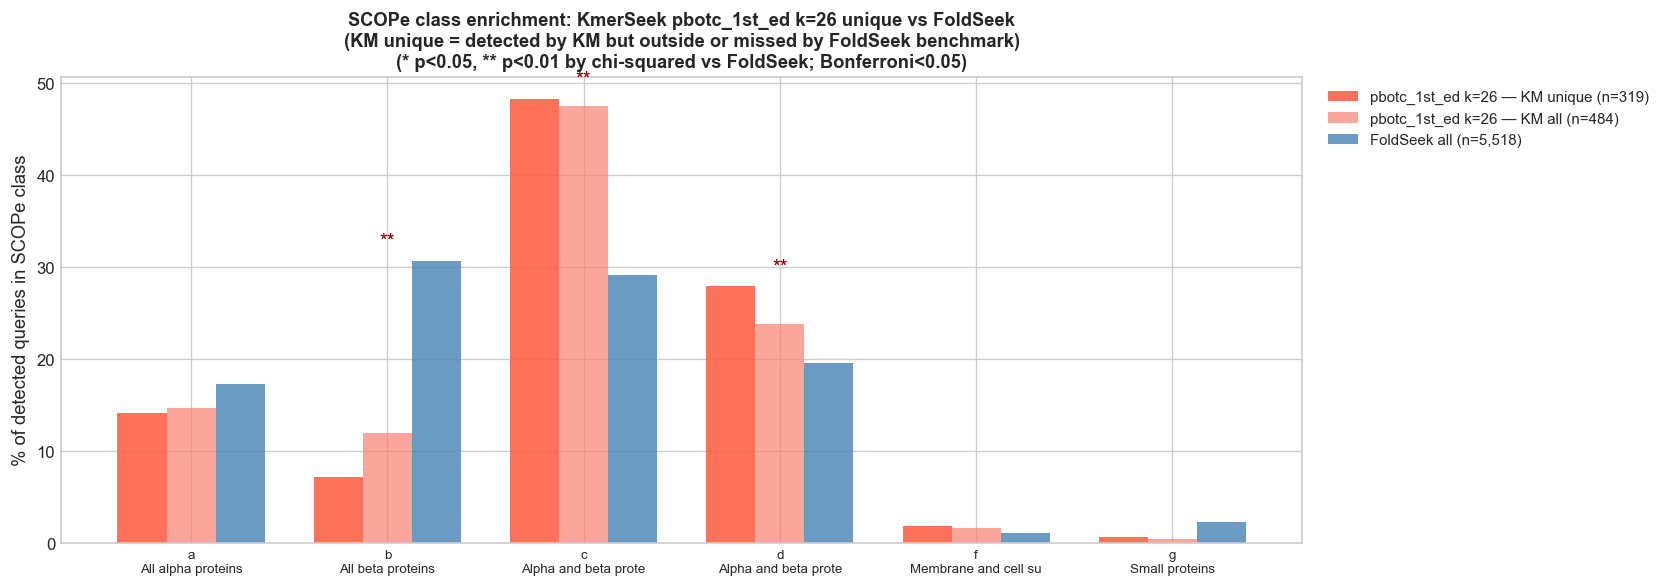

In [12]:
if auc_df.height > 0 and best_named is not None and enrichment_rows:
    desc_map = {c: SCOPE_CLASS_DESCRIPTIONS.get(c, c) for c in all_classes}
    x = np.arange(len(all_classes))
    w = 0.75 / 3

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - w,   [km_uniq_cls.get(c, 0) / max(n_km_u,   1) * 100 for c in all_classes],
           w, color='tomato',    alpha=0.9,
           label=f'{best_label.replace("hp_","")} k={best_k} — KM unique (n={n_km_u})')
    ax.bar(x,       [km_all_cls.get(c,  0) / max(n_km_all,  1) * 100 for c in all_classes],
           w, color='salmon',    alpha=0.7,
           label=f'{best_label.replace("hp_","")} k={best_k} — KM all (n={n_km_all})')
    ax.bar(x + w,   [fs_cls.get(c,      0) / max(n_fs,      1) * 100 for c in all_classes],
           w, color='steelblue', alpha=0.8, label=f'FoldSeek all (n={n_fs:,})')

    for i, row in enumerate(enrichment_rows):
        if not np.isnan(row['pval']) and row['pval'] < 0.05:
            y_top = max(
                km_uniq_cls.get(all_classes[i], 0) / max(n_km_u,   1) * 100,
                km_all_cls.get(all_classes[i],  0) / max(n_km_all,  1) * 100,
                fs_cls.get(all_classes[i],      0) / max(n_fs,      1) * 100,
            ) + 1.5
            sig_str = '**' if row['pval'] < 0.01 else '*'
            ax.text(x[i], y_top, sig_str, ha='center', fontsize=12, color='darkred')

    ax.set_xticks(x)
    ax.set_xticklabels([f'{c}\n{desc_map[c][:20]}' for c in all_classes], fontsize=8)
    ax.set_ylabel('% of detected queries in SCOPe class', fontsize=11)
    ax.set_title(
        f'SCOPe class enrichment: KmerSeek {best_label.replace("hp_","")} k={best_k} unique vs FoldSeek\n'
        f'(KM unique = detected by KM but outside or missed by FoldSeek benchmark)\n'
        f'(* p<0.05, ** p<0.01 by chi-squared vs FoldSeek; Bonferroni<{BONF_THRESHOLD})',
        fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'{FIG_PREFIX}_class_enrichment_chisq.png', dpi=150, bbox_inches='tight')
    plt.show()

### Omnibus tests: class distribution (χ² or Monte-Carlo χ²) + per-class Kruskal-Wallis ANOVA

**"Missed by FoldSeek"** = KmerSeek unique detections outside FoldSeek's benchmark coverage
(class e multidomain excluded from all analyses above).


Omnibus 6×2 — KM missed-by-FoldSeek vs FoldSeek class distribution
  Test: Monte-Carlo χ² (n_sim=99,999) (≥1 expected cell <5; asymptotic p unreliable)
  χ²=110.669  df=5  p=0.0000  ***
  Proceeding to per-class adjusted Pearson residuals (|r|>2.58 ≈ p<0.01 per cell).
  Classes with any E<5 flagged as undetermined.

  Class  KM-missed   E(KM)   FoldSeek   E(FS)   Adj.resid(KM)  Status
  ------------------------------------------------------------------------
  a        45 (  14%)   54.5     953 (  17%)  943.5           -1.46   ns   All alpha proteins
  b        23 (   7%)   93.7    1692 (  31%)  1621.3           -8.94   *** (depleted)   All beta proteins
  c       154 (  48%)   96.4    1609 (  29%)  1666.6           +7.23   *** (enriched)   Alpha and beta protein
  d        89 (  28%)   63.7    1077 (  20%)  1102.3           +3.64   *** (enriched)   Alpha and beta protein
  f         6 (   2%)    3.7      61 (   1%)   63.3             n/a   undetermined (E<5)   Membrane and cell surf
 

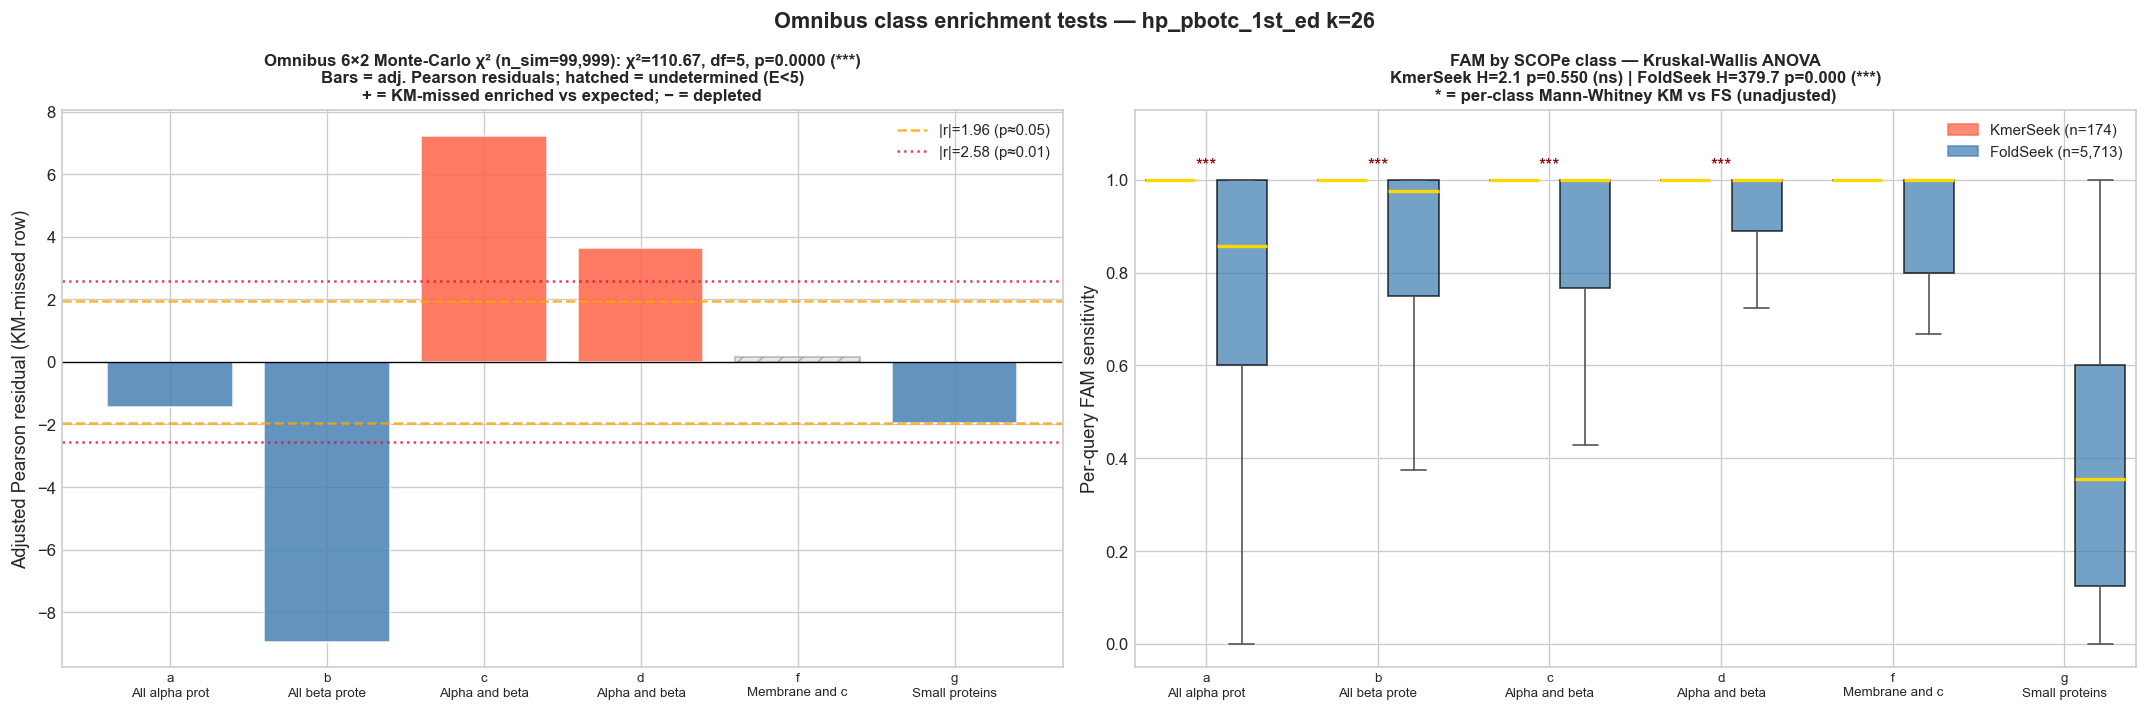

In [13]:
if auc_df.height > 0 and best_named is not None and enrichment_rows:
    from scipy.stats import chi2_contingency, kruskal, mannwhitneyu
    import matplotlib.patches as mpatches

    # ── 1. Build K×2 contingency table (class 'e' already removed upstream) ──
    classes_omni = sorted(c for c in (set(km_uniq_cls) | set(fs_cls)) if c != 'e')
    row_km = np.array([km_uniq_cls.get(c, 0) for c in classes_omni])
    row_fs = np.array([fs_cls.get(c, 0)      for c in classes_omni])
    contingency  = np.vstack([row_km, row_fs])   # shape (2, K)

    # ── 2. Choose test: standard χ² or Monte-Carlo χ² when any expected < 5 ──
    chi2_obs, p_chi2, dof_omni, expected = chi2_contingency(contingency, correction=False)
    E_MIN = 5
    any_small_E = bool(np.any(expected < E_MIN))

    if any_small_E:
        rng_mc    = np.random.default_rng(42)
        n_sim     = 99_999
        row_marg  = contingency.sum(axis=1)
        col_marg  = contingency.sum(axis=0)
        n_total   = int(contingency.sum())
        row_probs = row_marg / n_total
        # Vectorised MC: shape (n_sim, n_rows=2, K)
        all_sims = np.stack(
            [rng_mc.multinomial(int(ct), row_probs, size=n_sim) for ct in col_marg],
            axis=2,
        )
        sim_row = all_sims.sum(axis=2, keepdims=True)
        sim_col = all_sims.sum(axis=1, keepdims=True)
        sim_tot = all_sims.sum(axis=(1, 2), keepdims=True)
        sim_E   = sim_row * sim_col / sim_tot
        with np.errstate(divide='ignore', invalid='ignore'):
            sim_chi2 = np.where(sim_E > 0, (all_sims - sim_E) ** 2 / sim_E, 0.0).sum(axis=(1, 2))
        mc_extreme = int(np.sum(sim_chi2 >= chi2_obs))
        p_omni     = (mc_extreme + 1) / (n_sim + 1)
        test_name  = f"Monte-Carlo χ² (n_sim={n_sim:,})"
        test_why   = f"(≥1 expected cell <{E_MIN}; asymptotic p unreliable)"
    else:
        p_omni    = p_chi2
        test_name = "χ²"
        test_why  = f"(all expected cells ≥{E_MIN})"

    sig_omni = ("***" if p_omni < 0.001 else
                "**"  if p_omni < 0.01  else
                "*"   if p_omni < 0.05  else "ns")

    # ── 3. Adjusted standardized Pearson residuals ────────────────────────────
    # r_ij = (O_ij - E_ij) / sqrt(E_ij × (1 − row_i/n) × (1 − col_j/n))  ~ N(0,1) under H0
    n        = contingency.sum()
    row_tots = contingency.sum(axis=1, keepdims=True)
    col_tots = contingency.sum(axis=0, keepdims=True)
    denom    = np.sqrt(expected * (1 - row_tots / n) * (1 - col_tots / n))
    with np.errstate(invalid="ignore", divide="ignore"):
        adj_resid = np.where(denom > 0, (contingency - expected) / denom, np.nan)

    reliable = np.all(expected >= E_MIN, axis=0)   # shape (K,)

    # ── 4. Print omnibus result ───────────────────────────────────────────────
    print(f"Omnibus {len(classes_omni)}×2 — KM missed-by-FoldSeek vs FoldSeek class distribution")
    print(f"  Test: {test_name} {test_why}")
    print(f"  χ²={chi2_obs:.3f}  df={dof_omni}  p={p_omni:.4f}  {sig_omni}")
    if p_omni >= 0.05:
        print("  Omnibus test not significant — per-class residuals not reported.")
    else:
        print(f"  Proceeding to per-class adjusted Pearson residuals (|r|>2.58 ≈ p<0.01 per cell).")
        print(f"  Classes with any E<{E_MIN} flagged as undetermined.")
    print()
    print(f"  {'Class':<4}  {'KM-missed':>9} {'E(KM)':>7}  {'FoldSeek':>9} {'E(FS)':>7}  "
          f"{'Adj.resid(KM)':>14}  Status")
    print("  " + "-" * 72)
    for i, cls in enumerate(classes_omni):
        desc = SCOPE_CLASS_DESCRIPTIONS.get(cls, cls)[:22]
        r_km = adj_resid[0, i]
        if not reliable[i]:
            status = "undetermined (E<5)"
        elif np.isnan(r_km):
            status = "undetermined"
        elif abs(r_km) >= 2.576:
            status = f"*** ({'enriched' if r_km > 0 else 'depleted'})"
        elif abs(r_km) >= 1.96:
            status = f"*   ({'enriched' if r_km > 0 else 'depleted'})"
        else:
            status = "ns"
        resid_str = f"{r_km:+.2f}" if reliable[i] and not np.isnan(r_km) else "  n/a"
        print(
            f"  {cls:<4}  {contingency[0,i]:>5} ({contingency[0,i]/max(row_km.sum(),1)*100:4.0f}%)  "
            f"{expected[0,i]:>5.1f}   "
            f"{contingency[1,i]:>5} ({contingency[1,i]/max(row_fs.sum(),1)*100:4.0f}%)  "
            f"{expected[1,i]:>5.1f}   {resid_str:>13}   {status}   {desc}"
        )

    # ── 5. Kruskal-Wallis ANOVA — per-query FAM by class ─────────────────────
    print()
    kw_results = {}
    for method_label, rocx in [
        (f"KmerSeek {best_label} k={best_k}", km_rocx_r),
        ("FoldSeek", foldseek.filter(pl.col("NAME").is_in(ref_queries))),
    ]:
        cls_fam  = (rocx.select(["NAME", "FAM", "SCOP"])
                       .with_columns(pl.col("SCOP").str.slice(0, 1).alias("cls")))
        kw_classes = sorted(cls_fam["cls"].drop_nulls().unique().to_list())
        groups     = [(c, cls_fam.filter(pl.col("cls") == c)["FAM"].to_numpy())
                      for c in kw_classes]
        groups     = [(c, g) for c, g in groups if len(g) >= 3]
        if len(groups) < 2:
            continue
        H, p_kw = kruskal(*[g for _, g in groups])
        sig_kw  = ("***" if p_kw < 0.001 else "**" if p_kw < 0.01 else "*" if p_kw < 0.05 else "ns")
        kw_results[method_label] = (H, p_kw, sig_kw, groups)
        print(f"Kruskal-Wallis — {method_label} FAM by class  H={H:.3f}  p={p_kw:.4f}  {sig_kw}")
        for c, g in groups:
            desc = SCOPE_CLASS_DESCRIPTIONS.get(c, c)[:28]
            print(f"  {c:<4} n={len(g):>3}  median={np.median(g):.3f}  {desc}")
        print()

    # ── 6. Figure ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Left: adjusted Pearson residuals for KM-missed row
    ax = axes[0]
    residuals_km = adj_resid[0]
    bar_colors   = []
    hatches      = []
    for i in range(len(classes_omni)):
        if not reliable[i] or np.isnan(residuals_km[i]):
            bar_colors.append("lightgrey")
            hatches.append("//")
        else:
            bar_colors.append("tomato" if residuals_km[i] > 0 else "steelblue")
            hatches.append("")

    bars = ax.bar(np.arange(len(classes_omni)),
                  np.where(reliable & ~np.isnan(residuals_km), residuals_km, 0),
                  color=bar_colors, edgecolor="white", hatch=hatches, alpha=0.85)
    for i, (rel, r) in enumerate(zip(reliable, residuals_km)):
        if not rel or np.isnan(r):
            ax.bar(i, 0.15, color="lightgrey", hatch="//", alpha=0.5, edgecolor="grey")

    ax.axhline(0,     color="black",   lw=0.8)
    ax.axhline( 1.96, color="orange",  lw=1.5, ls="--", alpha=0.8, label="|r|=1.96 (p≈0.05)")
    ax.axhline(-1.96, color="orange",  lw=1.5, ls="--", alpha=0.8)
    ax.axhline( 2.576,color="crimson", lw=1.5, ls=":",  alpha=0.8, label="|r|=2.58 (p≈0.01)")
    ax.axhline(-2.576,color="crimson", lw=1.5, ls=":",  alpha=0.8)

    ax.set_xticks(np.arange(len(classes_omni)))
    ax.set_xticklabels(
        [f"{c}\n{SCOPE_CLASS_DESCRIPTIONS.get(c,c)[:14]}" for c in classes_omni], fontsize=8)
    ax.set_ylabel("Adjusted Pearson residual (KM-missed row)", fontsize=11)
    ax.set_title(
        f"Omnibus {len(classes_omni)}×2 {test_name}: χ²={chi2_obs:.2f}, df={dof_omni}, "
        f"p={p_omni:.4f} ({sig_omni})\n"
        f"Bars = adj. Pearson residuals; hatched = undetermined (E<{E_MIN})\n"
        f"+ = KM-missed enriched vs expected; − = depleted",
        fontsize=10, fontweight="bold")
    ax.legend(fontsize=9)

    # Right: FAM box plots by class (KM vs FS, covered queries only)
    ax = axes[1]
    km_cls_df = (km_rocx_r.select(["NAME", "FAM", "SCOP"])
                          .with_columns(pl.col("SCOP").str.slice(0, 1).alias("cls")))
    fs_cls_df = (foldseek.filter(pl.col("NAME").is_in(ref_queries))
                         .select(["NAME", "FAM", "SCOP"])
                         .with_columns(pl.col("SCOP").str.slice(0, 1).alias("cls")))
    anova_classes = sorted(set(km_cls_df["cls"].drop_nulls().unique().to_list()) |
                           set(fs_cls_df["cls"].drop_nulls().unique().to_list()))

    positions, data_list, colors_list = [], [], []
    tick_pos, tick_labels = [], []
    pos = 0
    for cls in anova_classes:
        tick_pos.append(pos + 0.5)
        tick_labels.append(f"{cls}\n{SCOPE_CLASS_DESCRIPTIONS.get(cls,cls)[:14]}")
        for df_, color in [(km_cls_df, "tomato"), (fs_cls_df, "steelblue")]:
            g = df_.filter(pl.col("cls") == cls)["FAM"].to_numpy()
            if len(g) > 0:
                positions.append(pos); data_list.append(g); colors_list.append(color)
            pos += 1
        pos += 0.4

    if data_list:
        bp = ax.boxplot(data_list, positions=positions, patch_artist=True, widths=0.7,
                        showfliers=False, medianprops=dict(color="gold", lw=2))
        for box, c in zip(bp["boxes"], colors_list):
            box.set_facecolor(c); box.set_alpha(0.75)
        for p_ in bp["whiskers"] + bp["caps"]:
            p_.set_color("#555")

    for cls in anova_classes:
        km_g = km_cls_df.filter(pl.col("cls") == cls)["FAM"].to_numpy()
        fs_g = fs_cls_df.filter(pl.col("cls") == cls)["FAM"].to_numpy()
        if len(km_g) >= 3 and len(fs_g) >= 3:
            _, p_cls = mannwhitneyu(km_g, fs_g, alternative="two-sided")
            sig = ("***" if p_cls < 0.001 else "**" if p_cls < 0.01 else "*" if p_cls < 0.05 else "")
            xi = anova_classes.index(cls)
            if sig:
                y_ann = max(np.percentile(km_g, 75), np.percentile(fs_g, 75)) + 0.05
                ax.text(tick_pos[xi], min(y_ann, 1.02), sig,
                        ha="center", fontsize=11, color="darkred")

    km_H, km_p = (kw_results[f"KmerSeek {best_label} k={best_k}"][:2]
                  if f"KmerSeek {best_label} k={best_k}" in kw_results else (float("nan"), float("nan")))
    fs_H, fs_p = (kw_results["FoldSeek"][:2] if "FoldSeek" in kw_results else (float("nan"), float("nan")))
    km_sig_kw  = "***" if km_p < 0.001 else "**" if km_p < 0.01 else "*" if km_p < 0.05 else "ns"
    fs_sig_kw  = "***" if fs_p < 0.001 else "**" if fs_p < 0.01 else "*" if fs_p < 0.05 else "ns"

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, fontsize=8)
    ax.set_ylabel("Per-query FAM sensitivity", fontsize=11)
    ax.set_title(
        f"FAM by SCOPe class — Kruskal-Wallis ANOVA\n"
        f"KmerSeek H={km_H:.1f} p={km_p:.3f} ({km_sig_kw}) | "
        f"FoldSeek H={fs_H:.1f} p={fs_p:.3f} ({fs_sig_kw})\n"
        f"* = per-class Mann-Whitney KM vs FS (unadjusted)",
        fontsize=10, fontweight="bold")
    ax.legend(handles=[
        mpatches.Patch(color="tomato",    alpha=0.75, label=f"KmerSeek (n={km_rocx_r.height})"),
        mpatches.Patch(color="steelblue", alpha=0.75, label=f"FoldSeek (n={len(ref_queries):,})"),
    ], fontsize=9)
    ax.set_ylim(-0.05, 1.15)

    plt.suptitle(
        f"Omnibus class enrichment tests — {best_label} k={best_k}",
        fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{FIG_PREFIX}_class_enrichment_omnibus.png", dpi=150, bbox_inches="tight")
    plt.show()


### KmerSeek vs FoldSeek — 2×2 detection-agreement matrix


=== 2×2 detection-agreement matrix (FoldSeek benchmark, class e excluded) ===
  Universe: 5,713 benchmark queries
  Both detected:          165  (2.9%)
  KmerSeek only (accent): 0  (0.0%)
  FoldSeek only:          5,353  (93.7%)
  Neither:                195  (3.4%)

=== Missed by FoldSeek (outside benchmark) ===
  KmerSeek detections outside FS benchmark: 319


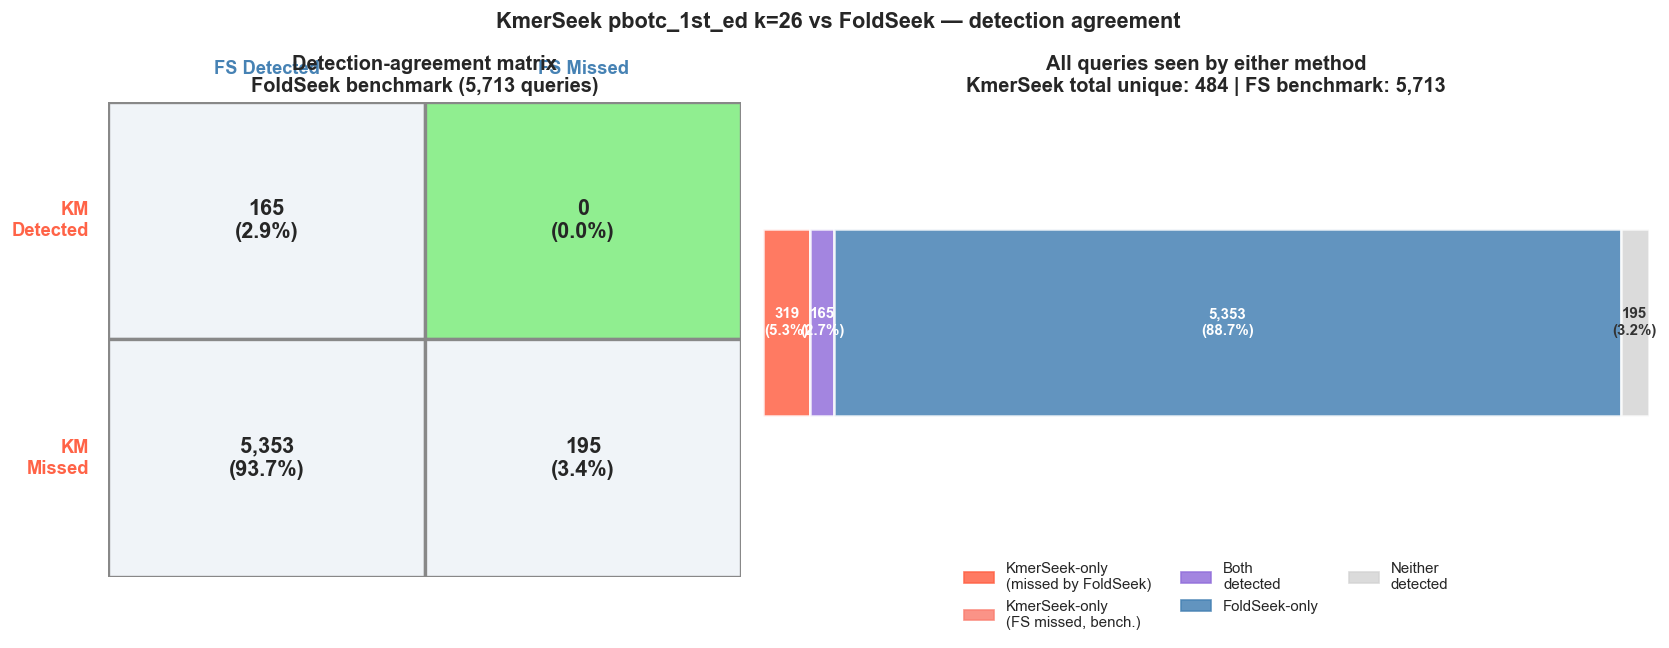

In [14]:
if auc_df.height > 0 and best_named is not None:
    import matplotlib.patches as mpatches

    # ── 2×2 detection-agreement matrix (head-to-head, FoldSeek benchmark) ─────
    # Rows = KmerSeek (detected / missed), Cols = FoldSeek (detected / missed)
    km_only_r = km_det_r - fs_det          # KM found, FS missed (benchmark)
    fs_only_r = fs_det   - km_det_r        # FS found, KM missed (benchmark)
    both_r    = km_det_r & fs_det          # both found (benchmark)
    neither_r = ref_queries - (km_det_r | fs_det)  # neither found

    n_bench = len(ref_queries)
    print("=== 2×2 detection-agreement matrix (FoldSeek benchmark, class e excluded) ===")
    print(f"  Universe: {n_bench:,} benchmark queries")
    print(f"  Both detected:          {len(both_r):,}  ({100*len(both_r)/n_bench:.1f}%)")
    print(f"  KmerSeek only (accent): {len(km_only_r):,}  ({100*len(km_only_r)/n_bench:.1f}%)")
    print(f"  FoldSeek only:          {len(fs_only_r):,}  ({100*len(fs_only_r)/n_bench:.1f}%)")
    print(f"  Neither:                {len(neither_r):,}  ({100*len(neither_r)/n_bench:.1f}%)")
    print()
    print(f"=== Missed by FoldSeek (outside benchmark) ===")
    print(f"  KmerSeek detections outside FS benchmark: {len(km_missed_by_fs):,}")

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1, 1.4]})

    # Left panel: 2×2 heatmap-style matrix
    ax = axes[0]
    ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.axis('off')

    ACCENT  = '#90EE90'   # soft green — KmerSeek-only cell (the key finding)
    NEUTRAL = '#f0f4f8'   # light grey — all other cells

    cell_data = [[len(both_r),    len(km_only_r)],
                 [len(fs_only_r), len(neither_r)]]
    cell_colors = [[NEUTRAL, ACCENT],
                   [NEUTRAL, NEUTRAL]]

    for r in range(2):
        for c in range(2):
            rect = plt.Rectangle((c, 1 - r), 1, 1,
                                  facecolor=cell_colors[r][c],
                                  edgecolor='#888', linewidth=2)
            ax.add_patch(rect)
            n_cell = cell_data[r][c]
            ax.text(c + 0.5, 1.5 - r,
                    f'{n_cell:,}\n({100*n_cell/n_bench:.1f}%)',
                    ha='center', va='center', fontsize=13, fontweight='bold')

    # Headers
    ax.text(0.5, 2.10, 'FS Detected',  ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='steelblue')
    ax.text(1.5, 2.10, 'FS Missed',    ha='center', va='bottom', fontsize=11,
            fontweight='bold', color='steelblue')
    ax.text(-0.06, 1.5, 'KM\nDetected', ha='right', va='center', fontsize=11,
            fontweight='bold', color='tomato')
    ax.text(-0.06, 0.5, 'KM\nMissed',   ha='right', va='center', fontsize=11,
            fontweight='bold', color='tomato')
    ax.set_title(
        f'Detection-agreement matrix\nFoldSeek benchmark ({n_bench:,} queries)',
        fontsize=12, fontweight='bold',
    )

    # Right panel: full-picture proportional bar
    ax = axes[1]
    segs = [
        (len(km_missed_by_fs), 'tomato',       0.85, 'KmerSeek-only\n(missed by FoldSeek)'),
        (len(km_only_r),       'salmon',        0.85, 'KmerSeek-only\n(FS missed, bench.)'),
        (len(both_r),          'mediumpurple',  0.85, 'Both\ndetected'),
        (len(fs_only_r),       'steelblue',     0.85, 'FoldSeek-only'),
        (len(neither_r),       'lightgrey',     0.80, 'Neither\ndetected'),
    ]
    total_all = len(km_missed_by_fs) + n_bench
    left = 0
    for n_seg, color, alpha, label in segs:
        w = n_seg / total_all * 100
        ax.barh(0, w, left=left, height=0.55,
                color=color, alpha=alpha, edgecolor='white', linewidth=1.5)
        if w > 2.5:
            ax.text(left + w / 2, 0,
                    f'{n_seg:,}\n({n_seg/total_all*100:.1f}%)',
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='white' if color != 'lightgrey' else '#333')
        left += w

    ax.set_xlim(0, 100); ax.set_ylim(-0.75, 0.65); ax.axis('off')
    handles = [mpatches.Patch(color=c, alpha=a, label=lbl) for _, c, a, lbl in segs]
    ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.14),
              ncol=3, fontsize=9, frameon=False)
    ax.set_title(
        f'All queries seen by either method\n'
        f'KmerSeek total unique: {len(km_det_all):,} | '
        f'FS benchmark: {n_bench:,}',
        fontsize=12, fontweight='bold',
    )

    plt.suptitle(
        f'KmerSeek {best_label.replace("hp_","")} k={best_k} vs FoldSeek — detection agreement',
        fontsize=13, fontweight='bold',
    )
    plt.tight_layout()
    plt.savefig(f'{FIG_PREFIX}_detection_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()


Missed-by-FoldSeek detected queries: 319

Top-hit TP/FP for 319 missed-by-FoldSeek detected queries:
  Same family (4-level):      300/319 = 94.0%
  Same superfamily (3-level): 319/319 = 100.0%
  Family mismatches:          19/319 = 6.0%

  All 19 "family mismatches" (should all be .0 vs classified, same superfamily):
    d3ucaa_       q_fam=a.128.1.0     t_fam=a.128.1.1     sfam_match=True  jaccard=0.0291
    d2egoa1       q_fam=b.36.1.0      t_fam=b.36.1.1      sfam_match=True  jaccard=0.0357
    d3fysa1       q_fam=c.119.1.0     t_fam=c.119.1.1     sfam_match=True  jaccard=0.0360
    d4imra1       q_fam=c.2.1.0       t_fam=c.2.1.2       sfam_match=True  jaccard=0.0243
    d1w6ua_       q_fam=c.2.1.2       t_fam=c.2.1.0       sfam_match=True  jaccard=0.0202
    d2c07a1       q_fam=c.2.1.2       t_fam=c.2.1.0       sfam_match=True  jaccard=0.0176
    d1ehia1       q_fam=c.30.1.2      t_fam=c.30.1.0      sfam_match=True  jaccard=0.0595
    d3tuic1       q_fam=c.37.1.12     t_fam=c.37.1

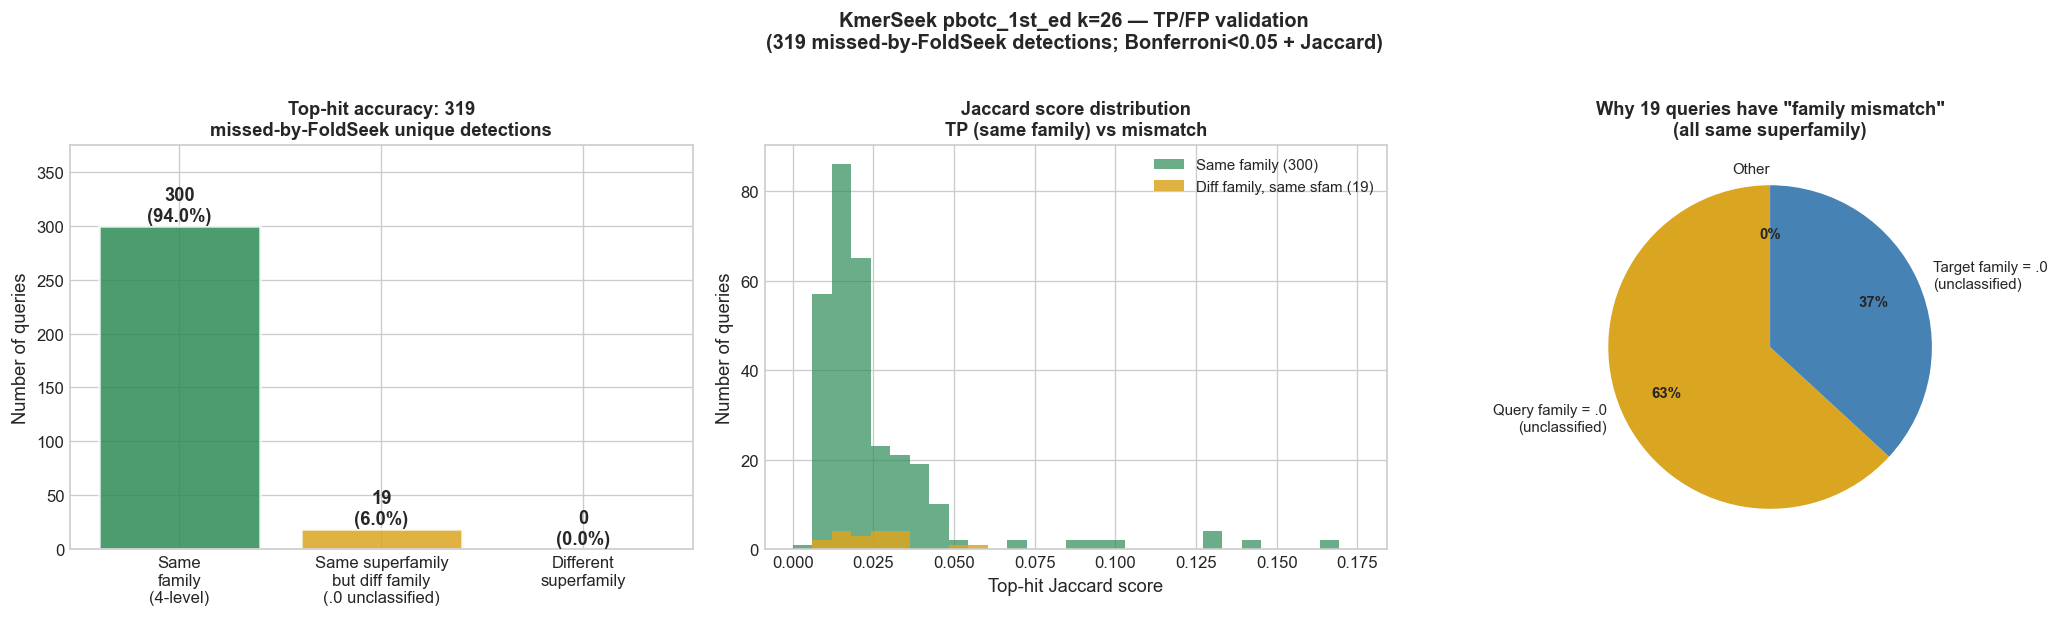

In [15]:
# TP/FP validation of the KmerSeek-unique "missed by FoldSeek" detections.
# For each query in km_missed_by_fs: is the top-ranked Jaccard hit in the same family?
# "Family mismatch" = different family number but still same superfamily (x.y.z.0 unclassified)

if best_named is None or auc_df.height == 0:
    print('No data.')
else:
    best_label, best_k = best_named

    ev_raw = pl.read_csv(eval_path(best_label, best_k), separator='\t')
    ev_tp  = add_composite_scores_scope(ev_raw)
    ev_tp  = recompute_bonferroni(ev_tp)
    ev_tp  = ev_tp.filter(pl.col('bonferroni_correct') < BONF_THRESHOLD)
    ev_tp  = ev_tp.with_columns(
        pl.col('query_name').str.split(' ').list.first().alias('_qid'),
        pl.col('target_name').str.split(' ').list.first().alias('_tid'),
    )

    # Use km_missed_by_fs (already class-e filtered) as the query set
    outside_det = km_missed_by_fs
    print(f'Missed-by-FoldSeek detected queries: {len(outside_det):,}')

    ev_out = ev_tp.filter(pl.col('_qid').is_in(outside_det))

    top_hits = (ev_out
        .sort('jaccard', descending=True)
        .group_by('_qid')
        .agg([
            pl.col('_tid').first().alias('top_target'),
            pl.col('jaccard').first().alias('top_jaccard'),
            pl.col('q_scop_family').first().alias('q_family'),
            pl.col('t_scop_family').first().alias('t_family'),
            pl.col('q_scop_superfamily').first().alias('q_sfam'),
            pl.col('t_scop_superfamily').first().alias('t_sfam'),
            pl.col('same_family').first().alias('top_same_family'),
            pl.col('same_superfamily').first().alias('top_same_sfam'),
        ])
    )
    del ev_raw, ev_tp, ev_out; gc.collect()

    n         = top_hits.height
    n_tp_fam  = top_hits.filter(pl.col('top_same_family') == True).height
    n_tp_sfam = top_hits.filter(pl.col('top_same_sfam')   == True).height
    n_fp_fam  = n - n_tp_fam

    tp_fp_stats = dict(n_tp_fam=n_tp_fam, n_tp_sfam=n_tp_sfam, pct_fam=100*n_tp_fam/max(n,1))

    print(f'\nTop-hit TP/FP for {n} missed-by-FoldSeek detected queries:')
    print(f'  Same family (4-level):      {n_tp_fam}/{n} = {100*n_tp_fam/max(n,1):.1f}%')
    print(f'  Same superfamily (3-level): {n_tp_sfam}/{n} = {100*n_tp_sfam/max(n,1):.1f}%')
    print(f'  Family mismatches:          {n_fp_fam}/{n} = {100*n_fp_fam/max(n,1):.1f}%')

    fp_rows = top_hits.filter(pl.col('top_same_family') == False).sort('q_family')
    print(f'\n  All {n_fp_fam} "family mismatches" (should all be .0 vs classified, same superfamily):')
    for row in fp_rows.iter_rows(named=True):
        print(f'    {row["_qid"]:12s}  q_fam={row["q_family"]:12s}  t_fam={row["t_family"]:12s}  '
              f'sfam_match={row["top_same_sfam"]}  jaccard={row["top_jaccard"]:.4f}')

    # ── Figure: TP/FP breakdown ───────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    n_diff_sfam = n - n_tp_sfam
    values = [n_tp_fam, n_fp_fam, n_diff_sfam]
    colors = ['seagreen', 'goldenrod', 'tomato']
    labels = ['Same\nfamily\n(4-level)', 'Same superfamily\nbut diff family\n(.0 unclassified)', 'Different\nsuperfamily']
    bars = ax.bar(labels, values, color=colors, alpha=0.85, edgecolor='white', lw=1.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({100*val/max(n,1):.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of queries', fontsize=11)
    ax.set_title(f'Top-hit accuracy: {n}\nmissed-by-FoldSeek unique detections', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.25)

    ax = axes[1]
    tp_jac = top_hits.filter(pl.col('top_same_family') == True)['top_jaccard'].to_numpy()
    fp_jac = top_hits.filter(pl.col('top_same_family') == False)['top_jaccard'].to_numpy()
    if len(tp_jac) > 0 or len(fp_jac) > 0:
        max_jac = max(tp_jac.max() if len(tp_jac) else 0, fp_jac.max() if len(fp_jac) else 0)
        bins = np.linspace(0, max_jac + 0.01, 30)
        if len(tp_jac): ax.hist(tp_jac, bins=bins, color='seagreen', alpha=0.7, label=f'Same family ({n_tp_fam})')
        if len(fp_jac): ax.hist(fp_jac, bins=bins, color='goldenrod', alpha=0.85, label=f'Diff family, same sfam ({n_fp_fam})')
    ax.set_xlabel('Top-hit Jaccard score', fontsize=11)
    ax.set_ylabel('Number of queries', fontsize=11)
    ax.set_title('Jaccard score distribution\nTP (same family) vs mismatch', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

    ax = axes[2]
    def last_component(fam_str):
        return fam_str.split('.')[-1] if fam_str else '?'
    q_last = [last_component(r['q_family']) for r in fp_rows.iter_rows(named=True)]
    t_last = [last_component(r['t_family']) for r in fp_rows.iter_rows(named=True)]
    counts = {'q_zero': 0, 't_zero': 0, 'other': 0}
    for q, t in zip(q_last, t_last):
        if q == '0':     counts['q_zero'] += 1
        elif t == '0':   counts['t_zero'] += 1
        else:            counts['other']  += 1
    pie_vals   = [counts['q_zero'], counts['t_zero'], counts['other']]
    pie_labels = ['Query family = .0\n(unclassified)', 'Target family = .0\n(unclassified)', 'Other']
    pie_colors = ['goldenrod', 'steelblue', 'tomato']
    if sum(pie_vals) > 0:
        wedges, texts, autotexts = ax.pie(
            pie_vals, labels=pie_labels, colors=pie_colors, autopct='%1.0f%%',
            startangle=90, pctdistance=0.7, textprops={'fontsize': 9})
        for at in autotexts: at.set_fontweight('bold')
    ax.set_title(f'Why {n_fp_fam} queries have "family mismatch"\n(all same superfamily)', fontsize=11, fontweight='bold')

    plt.suptitle(
        f'KmerSeek {best_label.replace("hp_","")} k={best_k} — TP/FP validation\n'
        f'({n} missed-by-FoldSeek detections; Bonferroni<{BONF_THRESHOLD} + Jaccard)',
        fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIG_PREFIX}_tp_fp_validation.png', dpi=150, bbox_inches='tight')
    plt.show()


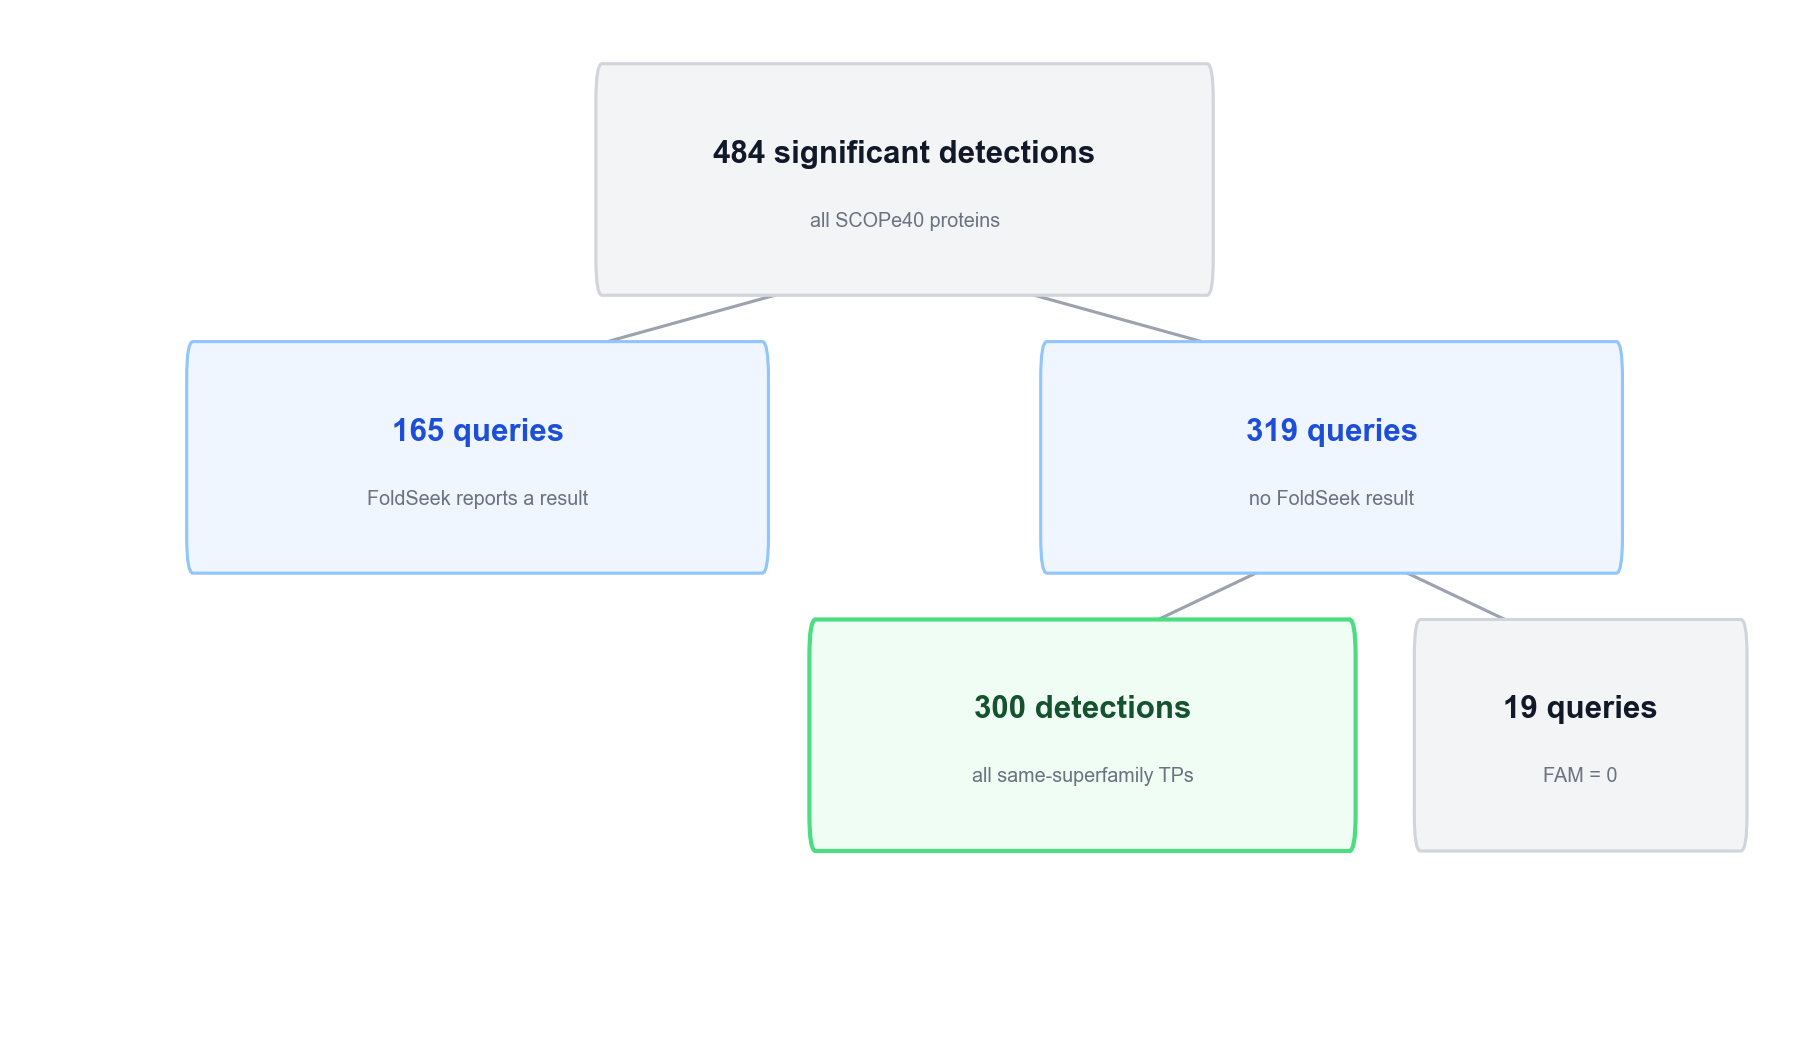

Saved: ../figures/076_336_breakdown.png


In [16]:
if best_named is None or auc_df.height == 0 or 'tp_fp_stats' not in dir():
    print('Run tp-fp-analysis cell first.')
else:
    import matplotlib.patches as mpatches

    n_total  = len(km_det_all)
    n_in_fs  = len(km_det_r)
    n_missed = len(km_missed_by_fs)
    n_val    = tp_fp_stats['n_tp_fam']
    n_no_fam = n_missed - n_val
    pct_fam  = tp_fp_stats['pct_fam']

    assert n_in_fs + n_missed == n_total
    assert n_val   + n_no_fam == n_missed

    # ── Style palette (matches reference design) ──────────────────────────────
    GREY_FILL  = '#f3f4f6';  GREY_EDGE  = '#d1d5db';  DARK_NUM  = '#111827'
    BLUE_FILL  = '#eff6ff';  BLUE_EDGE  = '#93c5fd';  BLUE_NUM  = '#1d4ed8'
    GREEN_FILL = '#f0fdf4';  GREEN_EDGE = '#4ade80';  GREEN_NUM = '#14532d'
    SUB_COL    = '#6b7280'
    ARROW_COL  = '#9ca3af'

    DPI = 150;  FIG_W = 12;  FIG_H = 7
    BH  = 1.55  # box height (data units)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), dpi=DPI)
    ax.set_xlim(0, 100);  ax.set_ylim(0, 10);  ax.axis('off')
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    def box(cx, cy, w, h, num_txt, sub_txt, fill, edge, num_col, edge_lw=1.5):
        ax.add_patch(mpatches.FancyBboxPatch(
            (cx - w/2, cy - h/2), w, h,
            boxstyle='round,pad=0.35', linewidth=edge_lw,
            facecolor=fill, edgecolor=edge, zorder=3))
        ax.text(cx, cy + h * 0.16, num_txt,
                ha='center', va='center', fontsize=15, fontweight='bold',
                color=num_col, zorder=4)
        ax.text(cx, cy - h * 0.26, sub_txt,
                ha='center', va='center', fontsize=9.5,
                color=SUB_COL, zorder=4)

    def arrow(x0, y0, x1, y1):
        ax.annotate('', xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color=ARROW_COL,
                                    lw=1.5, mutation_scale=12), zorder=2)

    # ── Tier 1: root ──────────────────────────────────────────────────────────
    T1Y = 8.4
    box(50, T1Y, 34, BH,
        f'{n_total:,} significant detections', 'all SCOPe40 proteins',
        GREY_FILL, GREY_EDGE, DARK_NUM)

    # ── Tier 2: split by FoldSeek benchmark coverage ──────────────────────────
    T2Y, T2L, T2R = 5.7, 26, 74
    box(T2L, T2Y, 32, BH,
        f'{n_in_fs:,} queries', 'FoldSeek reports a result',
        BLUE_FILL, BLUE_EDGE, BLUE_NUM)
    box(T2R, T2Y, 32, BH,
        f'{n_missed:,} queries', 'no FoldSeek result',
        BLUE_FILL, BLUE_EDGE, BLUE_NUM)

    # ── Tier 3: split by top-hit family match ─────────────────────────────────
    T3Y, T3L, T3R = 3.0, 60, 88
    box(T3L, T3Y, 30, BH,
        f'{n_val:,} detections', 'all same-superfamily TPs',
        GREEN_FILL, GREEN_EDGE, GREEN_NUM, edge_lw=2.0)
    box(T3R, T3Y, 18, BH,
        f'{n_no_fam:,} queries', 'FAM = 0',
        GREY_FILL, GREY_EDGE, DARK_NUM)

    # ── Arrows ────────────────────────────────────────────────────────────────
    arrow(50, T1Y - BH/2, T2L, T2Y + BH/2)
    arrow(50, T1Y - BH/2, T2R, T2Y + BH/2)
    arrow(T2R, T2Y - BH/2, T3L, T3Y + BH/2)
    arrow(T2R, T2Y - BH/2, T3R, T3Y + BH/2)

    plt.tight_layout(pad=0.5)
    plt.savefig(f'{FIG_PREFIX}_336_breakdown.png', dpi=DPI, bbox_inches='tight',
                facecolor='white')
    plt.show()
    print(f'Saved: {FIG_PREFIX}_336_breakdown.png')


### 3-method detection comparison: FoldSeek · TEA · KmerSeek

Pie chart and flowchart showing which SCOPe40 proteins are detected by each combination of methods, within the shared benchmark and across all SCOPe40.

  All 3 (FS+TEA+KM)                161  (1.1%)
  FS+TEA (not KM)                5,096  (34.3%)
  FS+KM  (not TEA)                   4  (0.0%)
  TEA+KM (not FS)                    0  (0.0%)
  FS only                          257  (1.7%)
  TEA only                          55  (0.4%)
  KM only                          319  (2.1%)
  None detected                  8,981  (60.4%)


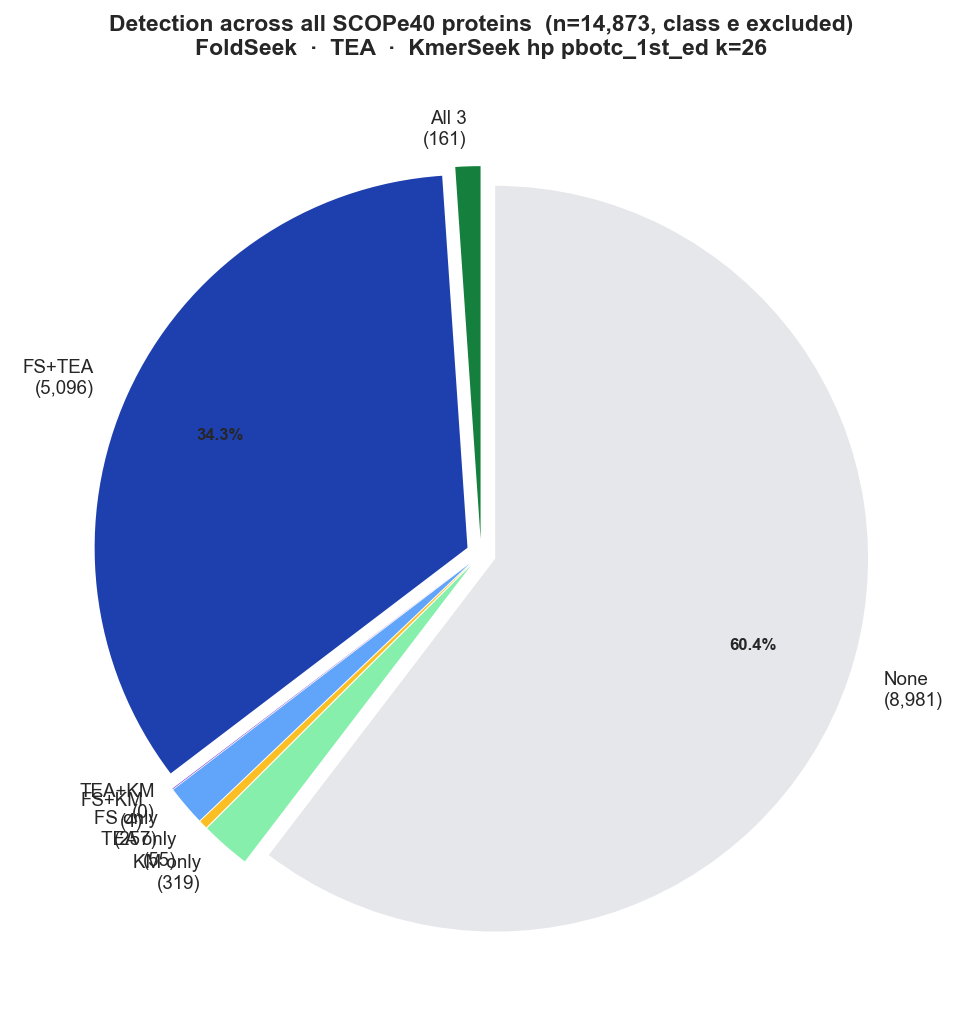

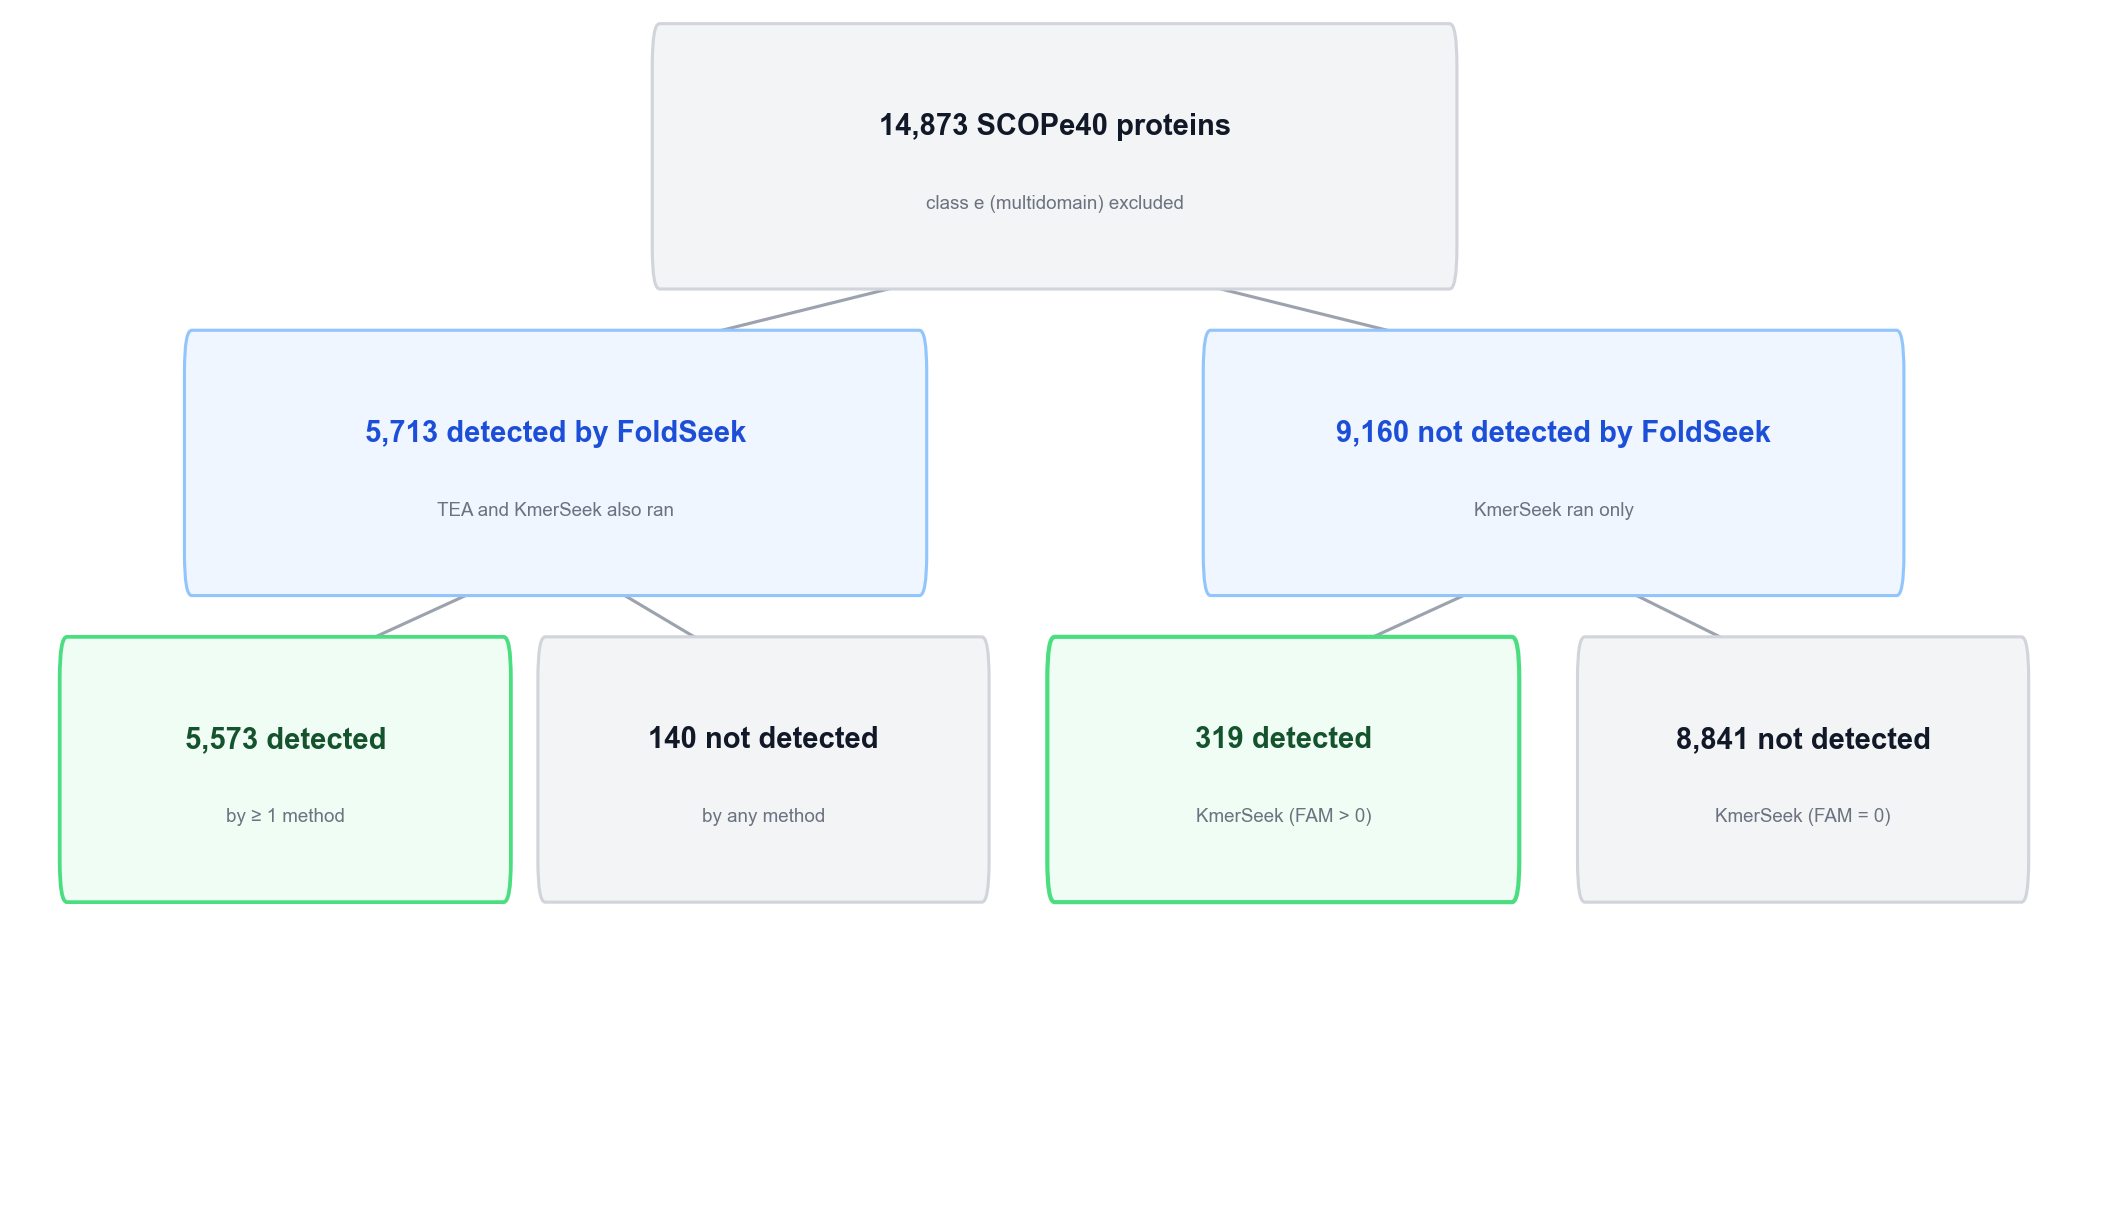

Saved: ../figures/076_3method_pie/flowchart.png


In [17]:
if auc_df.height == 0 or best_named is None:
    print('No data.')
else:
    import matplotlib.patches as mpatches
    best_label, best_k = best_named

    # ── TEA: drop class e, restrict to benchmark ──────────────────────────
    tea_det_r = set(
        tea_all.filter(
            (pl.col('SCOP').str.slice(0, 1) != 'e') &
            pl.col('NAME').is_in(ref_queries) &
            (pl.col('FAM') > 0)
        )['NAME'].to_list()
    )

    # ── Disjoint 3-way partition within FoldSeek-searched proteins ────────
    U       = ref_queries
    s_all3  = km_det_r & fs_det & tea_det_r
    s_fstea = (fs_det & tea_det_r) - km_det_r
    s_fskm  = (fs_det & km_det_r)  - tea_det_r
    s_teakm = (tea_det_r & km_det_r) - fs_det
    s_fs    = fs_det    - tea_det_r - km_det_r
    s_tea   = tea_det_r - fs_det    - km_det_r
    s_km    = km_det_r  - fs_det    - tea_det_r
    s_none  = U - (fs_det | tea_det_r | km_det_r)
    assert (s_all3|s_fstea|s_fskm|s_teakm|s_fs|s_tea|s_km|s_none) == U

    # ── Total SCOPe40 count (class e excluded) ────────────────────────────
    try:
        n_scope40 = sum(len(v) for k, v in cls_to_queries.items() if k != 'e')
    except NameError:
        n_scope40 = None
    if n_scope40:
        n_outside = n_scope40 - len(U)
        n_km_no   = n_outside - len(km_missed_by_fs)
    else:
        n_outside = n_km_no = None

    n_any_bm = len(U) - len(s_none)

    # Merge KM-only and None across all SCOPe40 (in and outside FS coverage)
    s_km_all   = s_km | km_missed_by_fs
    n_none_all = len(s_none) + (n_km_no or 0)

    for lbl, s in [
        ('All 3 (FS+TEA+KM)', s_all3), ('FS+TEA (not KM)', s_fstea),
        ('FS+KM  (not TEA)', s_fskm),  ('TEA+KM (not FS)', s_teakm),
        ('FS only', s_fs), ('TEA only', s_tea),
        ('KM only', s_km_all), ('None detected', None),
    ]:
        n = len(s) if s is not None else n_none_all
        denom = n_scope40 or len(U)
        print(f"  {lbl:<30} {n:>5,}  ({100*n/denom:.1f}%)")

    # ── Shared style ──────────────────────────────────────────────────────
    GREY_F = '#f3f4f6'; GREY_E = '#d1d5db'; DARK_N = '#111827'
    BLUE_F = '#eff6ff'; BLUE_E = '#93c5fd'; BLUE_N = '#1d4ed8'
    GRN_F  = '#f0fdf4'; GRN_E  = '#4ade80'; GRN_N  = '#14532d'
    SUB_C  = '#6b7280'; ARR_C  = '#9ca3af'

    # ═════════════════════════════════════════════════════════════════════
    # Figure 1: Pie chart — all SCOPe40 proteins, 3-method breakdown
    # ═════════════════════════════════════════════════════════════════════
    pie_sizes  = [len(s_all3), len(s_fstea), len(s_fskm), len(s_teakm),
                  len(s_fs),   len(s_tea),   len(s_km_all), n_none_all]
    pie_colors = ['#15803d', '#1e40af', '#7c3aed', '#d97706',
                  '#60a5fa', '#fbbf24', '#86efac', '#e5e7eb']
    pie_labels = [
        f'All 3\n({len(s_all3):,})',       f'FS+TEA\n({len(s_fstea):,})',
        f'FS+KM\n({len(s_fskm):,})',       f'TEA+KM\n({len(s_teakm):,})',
        f'FS only\n({len(s_fs):,})',        f'TEA only\n({len(s_tea):,})',
        f'KM only\n({len(s_km_all):,})',    f'None\n({n_none_all:,})',
    ]

    univ = n_scope40 or len(U)
    fig_pie, ax_pie = plt.subplots(figsize=(9, 7), dpi=150)
    fig_pie.patch.set_facecolor('white')
    _, _, autotexts = ax_pie.pie(
        pie_sizes, labels=pie_labels, colors=pie_colors,
        autopct=lambda p: f'{p:.1f}%' if p > 2.5 else '',
        explode=[0.04 if n > 0 else 0 for n in pie_sizes],
        startangle=90, pctdistance=0.73,
        textprops={'fontsize': 9},
    )
    for at in autotexts:
        at.set_fontsize(8); at.set_fontweight('bold')
    km_lbl = f'{best_label.replace("hp_", "hp ")} k={best_k}'
    ax_pie.set_title(
        f'Detection across all SCOPe40 proteins  (n={univ:,}, class e excluded)\n'
        f'FoldSeek  ·  TEA  ·  KmerSeek {km_lbl}',
        fontsize=11, fontweight='bold', pad=16)
    fig_pie.tight_layout()
    fig_pie.savefig(f'{FIG_PREFIX}_3method_pie.png', dpi=150,
                    bbox_inches='tight', facecolor='white')
    plt.show()

    # ═════════════════════════════════════════════════════════════════════
    # Figure 2: Flowchart — full SCOPe40 picture
    # ═════════════════════════════════════════════════════════════════════
    BH = 1.55
    fig_fc, ax_fc = plt.subplots(figsize=(14, 8), dpi=150)
    fig_fc.patch.set_facecolor('white')
    ax_fc.set_xlim(0, 100); ax_fc.set_ylim(0, 10); ax_fc.axis('off')

    def bx(cx, cy, w, num_txt, sub_txt, fill, edge, nc, lw=1.5):
        ax_fc.add_patch(mpatches.FancyBboxPatch(
            (cx - w/2, cy - BH/2), w, BH,
            boxstyle='round,pad=0.35', linewidth=lw,
            facecolor=fill, edgecolor=edge, zorder=3))
        ax_fc.text(cx, cy + BH * 0.16, num_txt,
                   ha='center', va='center', fontsize=14,
                   fontweight='bold', color=nc, zorder=4)
        if sub_txt:
            ax_fc.text(cx, cy - BH * 0.26, sub_txt,
                       ha='center', va='center', fontsize=9,
                       color=SUB_C, zorder=4)

    def arw(x0, y0, x1, y1):
        ax_fc.annotate('', xy=(x1, y1), xytext=(x0, y0),
                       arrowprops=dict(arrowstyle='->', color=ARR_C,
                                       lw=1.5, mutation_scale=12), zorder=2)

    if n_scope40:
        T1Y = 8.8
        bx(50, T1Y, 38, f'{n_scope40:,} SCOPe40 proteins',
           'class e (multidomain) excluded',
           GREY_F, GREY_E, DARK_N)
        T2Y = 6.2
        bx(26, T2Y, 35, f'{len(U):,} detected by FoldSeek',
           'TEA and KmerSeek also ran',
           BLUE_F, BLUE_E, BLUE_N)
        bx(74, T2Y, 33, f'{n_outside:,} not detected by FoldSeek',
           'KmerSeek ran only',
           BLUE_F, BLUE_E, BLUE_N)
        T3Y = 3.6
        bx(13, T3Y, 21, f'{n_any_bm:,} detected',
           'by ≥ 1 method', GRN_F, GRN_E, GRN_N, lw=1.8)
        bx(36, T3Y, 21, f'{len(s_none):,} not detected',
           'by any method', GREY_F, GREY_E, DARK_N)
        bx(61, T3Y, 22, f'{len(km_missed_by_fs):,} detected',
           'KmerSeek (FAM > 0)', GRN_F, GRN_E, GRN_N, lw=2.0)
        bx(86, T3Y, 21, f'{n_km_no:,} not detected',
           'KmerSeek (FAM = 0)', GREY_F, GREY_E, DARK_N)
        arw(50, T1Y - BH/2, 26, T2Y + BH/2)
        arw(50, T1Y - BH/2, 74, T2Y + BH/2)
        arw(26, T2Y - BH/2, 13, T3Y + BH/2)
        arw(26, T2Y - BH/2, 36, T3Y + BH/2)
        arw(74, T2Y - BH/2, 61, T3Y + BH/2)
        arw(74, T2Y - BH/2, 86, T3Y + BH/2)
    else:
        T1Y = 7.5
        bx(50, T1Y, 36, f'{len(U):,} detected by FoldSeek',
           'TEA and KmerSeek also ran (class e excluded)',
           GREY_F, GREY_E, DARK_N)
        T2Y = 4.8
        bx(25, T2Y, 32, f'{n_any_bm:,} detected',
           'by ≥ 1 method', GRN_F, GRN_E, GRN_N, lw=1.8)
        bx(65, T2Y, 30, f'{len(s_none):,} not detected',
           'by any method', GREY_F, GREY_E, DARK_N)
        arw(50, T1Y - BH/2, 25, T2Y + BH/2)
        arw(50, T1Y - BH/2, 65, T2Y + BH/2)

    fig_fc.tight_layout(pad=0.5)
    fig_fc.savefig(f'{FIG_PREFIX}_3method_flowchart.png', dpi=150,
                   bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {FIG_PREFIX}_3method_pie/flowchart.png')
